# 机器学习实验4：分类任务（聚类）

## 3.1 数据预处理
在本次数据预处理任务中，我们的核心目标是将 “ASI 分类.xls” 转换为可直接用于监督学习分类的数据集，既要保留原始地质意义，又要解决数据类型不统一、缺失值、目标泄露等问题，同时保证实验的公平性与可复现性。  
原始数据存在明显短板：大量化学成分列（如 TiO₂、MgO，以及从 Ga 到 Cs 的微量 / 稀土元素）因包含 “n.d.”“<” 等非数字字符，被识别为文本类型（object）。这直接导致数值计算、标准化无法开展，缺失值位置也难以精准识别。对此，我们先正确设置表头（跳过第一行无效索引）将数据读入 DataFrame，再把 33 列应是数值的列强制转换为数值类型，不可解析的条目统一标记为 NaN，最终产出 “ASI_data_cleaned.csv”，为后续步骤奠定纯数值型数据基础。  
预处理流水线的设计环环相扣且逻辑清晰。首先划定特征与目标，剔除可能导致目标泄露或无意义的列：将 No.（无信息的编号）、Type 和 Type-1（与目标同义，易引发目标泄露）从特征中移除，仅以 Type 作为目标变量，并将其编码为 0、1、2（契合机器学习通用规范）。接着，剔除缺失率超过 40% 的特征列，这类列插补可靠性低且易放大噪声，先降维能提升模型稳健性，且该操作不依赖标签，不会造成信息泄露。  
在划分训练集与测试集时，采用 80/20 的比例，结合分层抽样（stratify=y）与固定随机种子（random_state=42），既保证了两类数据中各类别比例一致，又实现了结果可复现，避免了因提前查看测试集统计信息导致的信息泄露。对于缺失值处理和特征标准化，我们严格遵循 “仅用训练集学习参数” 的原则：缺失值采用 KNNImputer（k=5）插补，这是因为地球化学数据存在强相关性（如 SiO₂升高常伴随 MgO 降低，A-type 花岗岩富集 Zr、Y、Nb 等），KNN 能按 “地球化学相似度” 找邻居并以局部均值填补，保留元素间真实关联；若用均值 / 中位数插补，会破坏这种关联生成 “假样本”。特征标准化则通过 StandardScaler 实现，统一量纲以避免大数值特征主导模型，同样在训练集上拟合参数后再转换测试集，防止数据泄露。  
关键设计选择均有实务依据：缺失阈值 40% 是兼顾数据利用率与插补可靠性的折中；KNNImputer 的 k 取 5，平衡了噪声影响与过度平滑的风险，后续还可在验证环节调参（如 3、5、7）；标签从 0 开始编码符合 sklearn 分类器的普遍约定；分层抽样加固定随机种子则保障了类别比例稳定与实验可复现性。  
从数据质量看，清洗后 49 个数值列可用于建模，但微量元素缺失仍较多（如 Ga 缺失 124 个、Pb 缺失 384 个、Cs 缺失 601 个），这也进一步印证了 “先删高缺失列、再对剩余缺失做 KNN 插补” 这一流程的合理性与必要性。  
最终产出的 “ASI_data_cleaned.csv” 是文本转数值后的清洗版，便于审阅复用；“train_processed.csv” 和 “test_processed.csv” 则是完成插补与标准化的 “模型就绪” 数据，实现了预处理与建模的解耦，为多模型公平对比和实验复现提供了便利。

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
# --- 新增的库 (为了实现聚类和标签对齐) ---
from sklearn.cluster import KMeans 
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.optimize import linear_sum_assignment
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

print("机器学习数据预处理流程")

try:
   
    # 1. & 2. 加载原始 Excel 文件并进行初次清理
    print("步骤 1/9: 加载原始 Excel 文件 'ASI分类.xls' ")
    df = pd.read_excel("ASI分类.xls", sheet_name="Sheet1", header=1) 

    print("步骤 2/9: 正在清理数据（将文本列转换为数字）...")
    try:
        start_col_index = df.columns.get_loc('SiO2')
        end_col_col = 'Cs ' if 'Cs ' in df.columns else 'Cs'
        if end_col_col not in df.columns:
             print(f"警告: 找不到 '{end_col_col}' 列, 转换到 'U' 列为止")
             end_col_index = df.columns.get_loc('U')
        else:
             end_col_index = df.columns.get_loc(end_col_col)

        cols_to_convert = df.columns[start_col_index : end_col_index + 1]
        
        converted_count = 0
        for col in cols_to_convert:
            if df[col].dtype == 'object':
                df[col] = pd.to_numeric(df[col], errors='coerce')
                converted_count += 1
        print(f"数据类型清理完毕。转换了 {converted_count} 个 'object' 列为 'numeric'。")

    except KeyError as e:
        print(f"警告: 找不到关键列 ({e})。跳过自动类型转换。")

    print(f"数据加载和清理完毕。 初始形状: {df.shape}")

    # 3. 定义特征 (X) 和目标 (y)
    print("步骤 3/9: 定义特征 (X) 和目标 (y)...")
    cols_to_drop_initial = ['No.', 'Type', 'Type-1']
    cols_present = [col for col in cols_to_drop_initial if col in df.columns]
    X = df.drop(columns=cols_present)
    
    if 'Type' in df.columns:
        y = df['Type']
    else:
        raise ValueError("目标列 'Type' 在数据中未找到。")
    
    print(f"X (特征) 初始形状: {X.shape}")

    # 4. 剔除高缺失率特征
    print("步骤 4/9: 正在剔除缺失率 > 40% 的列...")
    missing_percentage = X.isnull().mean()
    cols_to_drop_missing = missing_percentage[missing_percentage > 0.4].index
    
    X = X.drop(columns=cols_to_drop_missing)
    
    if len(cols_to_drop_missing) > 0:
        print(f"已删除 {len(cols_to_drop_missing)} 个高缺失列: {list(cols_to_drop_missing)}")
    else:
        print("没有列的缺失率超过 40%。")
    print(f"X (特征) 剔除后形状: {X.shape}")
    
    # 5. 编码目标变量 (y)
    print("步骤 5/9: 正在编码目标变量 'Type' (A=0, I=1, S=2)...")
    le = LabelEncoder()
    y_clean = y.dropna()
    y_indices = y_clean.index
    X_clean = X.loc[y_indices]
    
    y_encoded = le.fit_transform(y_clean)
    print(f"目标 'Type' 已被编码: {list(le.classes_)} -> {list(range(len(le.classes_)))}")

    # 6. 拆分数据为训练集和测试集
    print("步骤 6/9: 正在拆分训练集和测试集 (80/20 分层抽样)...")
    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y_encoded, 
        test_size=0.2, 
        random_state=42, 
        stratify=y_encoded 
    )
    print(f"训练集形状: X_train: {X_train.shape}, y_train: {y_train.shape}")
    print(f"测试集形状: X_test: {X_test.shape}, y_test: {y_test.shape}")
    
    feature_names = X_clean.columns

    # 7. 插补缺失值 (KNNImputer)
    print(f"步骤 7/9: 正在使用 KNNImputer (k=5) 智能插补缺失值...")
    imputer = KNNImputer(n_neighbors=5)
    X_train_imputed = imputer.fit_transform(X_train)
    X_test_imputed = imputer.transform(X_test)
    print("插补完成。")

    # 8. 特征标准化 (StandardScaler)
    print("步骤 8/9: 正在使用 StandardScaler 标准化所有特征...")
    scaler = StandardScaler()
    X_train_processed = scaler.fit_transform(X_train_imputed)
    X_test_processed = scaler.transform(X_test_imputed)
    print("标准化完成。")


    print("\n流程全部完成。")

except FileNotFoundError:
    print(f"\n--- 错误: 文件未找到 ---")
    print(f"找不到文件 'ASI分类.xls'。")
except ImportError:
    print(f"\n--- 错误: 缺少库 ---")
    print("请先安装 'openpyxl' 库来读取 Excel 文件。")
except Exception as e:
    print(f"\n--- 处理过程中发生错误 ---")
    print(f"错误详情: {e}")

机器学习数据预处理流程
步骤 1/9: 加载原始 Excel 文件 'ASI分类.xls' 
步骤 2/9: 正在清理数据（将文本列转换为数字）...
数据类型清理完毕。转换了 32 个 'object' 列为 'numeric'。
数据加载和清理完毕。 初始形状: (1341, 50)
步骤 3/9: 定义特征 (X) 和目标 (y)...
X (特征) 初始形状: (1341, 47)
步骤 4/9: 正在剔除缺失率 > 40% 的列...
已删除 1 个高缺失列: ['Cs ']
X (特征) 剔除后形状: (1341, 46)
步骤 5/9: 正在编码目标变量 'Type' (A=0, I=1, S=2)...
目标 'Type' 已被编码: ['A-type', 'I-type', 'S-type'] -> [0, 1, 2]
步骤 6/9: 正在拆分训练集和测试集 (80/20 分层抽样)...
训练集形状: X_train: (1072, 46), y_train: (1072,)
测试集形状: X_test: (269, 46), y_test: (269,)
步骤 7/9: 正在使用 KNNImputer (k=5) 智能插补缺失值...
插补完成。
步骤 8/9: 正在使用 StandardScaler 标准化所有特征...
标准化完成。

流程全部完成。


#### 基础模型  

首先是数据准备与清洗环节：代码优先尝试读取 Excel 格式的 “ASI 分类.xls” 数据（Sheet1 工作表，从第 2 行开始读取表头），若读取失败则 fallback 到 CSV 格式文件；随后聚焦数据中的化学元素特征（从 SiO₂列到 Cs/U 列，覆盖关键元素指标），将非数值数据转为缺失值（coerce 模式）；进一步筛选特征（删除缺失率超 40% 的无效特征）与样本（剔除真实标签 Type 缺失的样本），最终分离出特征矩阵 X（不含编号、标签等非特征列）与真实标签 y（样本 Type），并通过 LabelEncoder 将文本 / 类别标签 y 转为数值编码（便于后续评估）。  
接着是数据预处理环节：考虑到实验数据可能存在缺失值与特征量级差异，代码先用 KNNImputer（5 个近邻）对训练集缺失值进行插补（测试集沿用训练集插补规则，避免数据泄露），再通过 StandardScaler 对特征做标准化（消除量级影响，适配 K-Means 的距离计算逻辑）；同时采用分层抽样（stratify=y_encoded）将清洗后的数据按 8:2 拆分为训练集与测试集，确保两类数据集的标签分布一致，提升评估可靠性。  
然后是降维与聚类建模环节：为解决高维特征的 “维数灾难”（避免聚类时距离计算失效、提升效率），代码用 PCA（主成分分析）进行无监督降维，设置保留 95% 信息的阈值，自动筛选核心主成分（输出降维前后的特征数对比，直观体现降维效果）；随后构建 K-Means 聚类模型（指定 3 个簇，对应样本的真实分类数量；n_init=20 避免局部最优解），基于降维后的训练集主成分完成聚类训练。  
最后是模型评估与过拟合检测环节：由于 K-Means 的聚类标签是随机生成的（与真实 Type 标签无直接对应关系），代码设计了专属评估函数 —— 通过 confusion_matrix（混淆矩阵）与 linear_sum_assignment（匈牙利算法）对齐聚类标签与真实标签，实现 “簇→类别” 的精准映射；在此基础上计算训练集 / 测试集准确率，通过两者差值（小于 5% 视为无显著过拟合）判断模型泛化能力；同时输出详细分类报告（含各类别 F1-Score、精确率、召回率）与加权 F1-Score，全面验证聚类对不同类别样本的分类效果。  
此外，代码还包含异常处理（捕获运行错误并打印原因）与警告屏蔽（忽略无关警告信息），确保实验流程稳定运行，整体逻辑贴合 “数据预处理→降维优化→无监督聚类→有监督验证” 的机器学习实验范式，尤其适用于化学、地质等依赖元素特征的样本分类场景。

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report
from scipy.optimize import linear_sum_assignment
import warnings
warnings.filterwarnings('ignore')

print("Part 1: 基础实验 (PCA + K-Means)")

try:
    # 1. 数据准备
    try:
        df = pd.read_excel("ASI分类.xls", sheet_name="Sheet1", header=1)
    except:
        df = pd.read_csv("ASI分类(1).xls - Sheet1.csv", header=1)

    # 清洗
    start = df.columns.get_loc('SiO2')
    end = df.columns.get_loc('Cs ' if 'Cs ' in df.columns else ('Cs' if 'Cs' in df.columns else 'U'))
    for col in df.columns[start : end+1]:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    X = df.drop(columns=['No.', 'Type', 'Type-1'])
    X = X.drop(columns=X.columns[X.isnull().mean() > 0.4])
    y = df['Type']

    le = LabelEncoder()
    y_clean = y.dropna()
    X_clean = X.loc[y_clean.index]
    y_encoded = le.fit_transform(y_clean)

    # 2. 拆分
    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    # 3. 预处理 (插补+标准化)
    imputer = KNNImputer(n_neighbors=5)
    scaler = StandardScaler()
    
    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp = imputer.transform(X_test)
    
    X_train_sc = scaler.fit_transform(X_train_imp)
    X_test_sc = scaler.transform(X_test_imp)

    # 4. PCA 降维 (纯无监督)
    # 保留 95% 的信息，去噪
    pca = PCA(n_components=0.95, random_state=42)
    X_train_pca = pca.fit_transform(X_train_sc)
    X_test_pca = pca.transform(X_test_sc)
    
    print(f"PCA 降维完成: 特征数从 {X_train_sc.shape[1]} -> {X_train_pca.shape[1]}")

    # 5. K-Means 聚类
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
    kmeans.fit(X_train_pca)

    print("\n基础模型评估报告 ")

    # 辅助函数：自动对齐标签并计算指标
    def evaluate(y_true, y_pred_raw, name="数据集"):
        cm = confusion_matrix(y_true, y_pred_raw)
        row_ind, col_ind = linear_sum_assignment(-cm)
        mapping = {c: t for t, c in zip(row_ind, col_ind)}
        y_pred_mapped = [mapping[x] for x in y_pred_raw]
        
        acc = accuracy_score(y_true, y_pred_mapped)
        return acc, y_pred_mapped

    # A. 过拟合检测
    y_pred_train_raw = kmeans.predict(X_train_pca)
    train_acc, _ = evaluate(y_train, y_pred_train_raw, "训练集")
    
    y_pred_test_raw = kmeans.predict(X_test_pca)
    test_acc, y_pred_test_mapped = evaluate(y_test, y_pred_test_raw, "测试集")

    print(f"训练集准确率: {train_acc:.2%}")
    print(f"测试集准确率: {test_acc:.2%}")
    
    diff = train_acc - test_acc
    if abs(diff) < 0.05:
        print("✅ 模型状态: 没有过拟合 (但可能欠拟合，即怎么学都学不会)")
    else:
        print(f"⚠️ 模型状态: 存在差异 ({diff:.1%})")

    # B. 详细分类报告 (F1-Score)
    print("\n 详细分类表现 ")
    print(classification_report(y_test, y_pred_test_mapped, target_names=le.classes_))
    
    f1 = f1_score(y_test, y_pred_test_mapped, average='weighted')
    print(f"综合 F1-Score: {f1:.4f}")

except Exception as e:
    print(f"运行出错: {e}")

--- Part 1: 基础实验 (PCA + K-Means) ---
PCA 降维完成: 特征数从 46 -> 17

=== 基础模型评估报告 ===
训练集准确率: 40.58%
测试集准确率: 40.15%
✅ 模型状态: 没有过拟合 (但可能欠拟合，即怎么学都学不会)

--- 详细分类表现 ---
              precision    recall  f1-score   support

      A-type       0.54      0.55      0.55       155
      I-type       0.31      0.27      0.29        81
      S-type       0.00      0.00      0.00        33

    accuracy                           0.40       269
   macro avg       0.28      0.28      0.28       269
weighted avg       0.41      0.40      0.40       269

综合 F1-Score: 0.4032


#### 关键特征筛选 + PCA降维 + K-Means   
代码首先实现高容错性的数据加载：优先读取 Excel 格式数据，若文件缺失则自动切换至 CSV 格式，随后聚焦岩石分类核心的 “化学元素特征列”（从 SiO₂列到 Cs/U 列），将非数值数据转为缺失值，并过滤缺失率超 40% 的无效特征与标签缺失的样本，确保建模数据质量。关键优化点在于 “基于地质常识的特征筛选”—— 摒弃全量特征，仅保留 SiO₂、Al₂O₃、A/CNK、K₂O、Na₂O 这 5 个地质领域区分岩石类型的核心主量元素，既降低计算成本，又让聚类逻辑贴合真实分类规律。  
预处理阶段，代码用 KNN 近邻插补（5 个近邻）填充缺失值，再通过标准化消除特征量级差异，避免某类元素主导聚类结果。建模时，为适配可视化需求，将关键特征通过 PCA 强制降维至 2 维，随后用 K-Means（设 3 个簇，对应样本真实类型数）完成聚类，并通过匈牙利算法对齐 “随机生成的聚类标签” 与 “真实样本标签”，确保准确率、F1-Score 计算准确。  
从运行结果看，模型训练集与测试集准确率均约 49%，加权 F1 值 0.4901，触发 “欠拟合警告”，说明仅依靠主量元素难以有效区分 ASI 岩石类型。为直观解读问题，代码生成 3 张针对性图表：PCA 空间散点图对比真实分类与聚类结果，混淆矩阵热力图呈现错判分布，PCA 维度密度图展示数据重叠情况，还附带通俗解读提示（如 “密度图波峰重叠则主量元素区分度不足”），帮助非技术人员理解数据特性。整体而言，代码既体现了地质领域的专业适配性，又通过可视化与评估逻辑，清晰暴露了 “主量元素特征不足” 的核心问题，为后续补充微量元素等优化方向提供了依据。

--- 进阶优化方案：关键特征筛选 + PCA降维 + K-Means (可视化增强版) ---
步骤 1: 加载原始数据...
  -> 数据加载成功，样本数: 1341
步骤 9-Opt: 正在筛选关键地质特征...
  -> 选用的关键特征: ['SiO2', 'Al2O3', 'A/CNK', 'K2O', 'Na2O']
步骤 9a: 执行 PCA 降维...
步骤 9b: 执行 K-Means 聚类...

========== PCA + K-Means 模型体检报告 ==========
训练集准确率: 49.07%
测试集准确率: 48.70%
测试集 F1分 : 0.4901
------------------------------
⚠️ 警告: 存在欠拟合风险 (准确率较低，说明仅靠主量元素很难区分)

详细分类报告:
              precision    recall  f1-score   support

      A-type       0.62      0.63      0.62       155
      I-type       0.39      0.33      0.36        81
      S-type       0.16      0.21      0.18        33

    accuracy                           0.49       269
   macro avg       0.39      0.39      0.39       269
weighted avg       0.50      0.49      0.49       269

正在生成 3 张分析图表...


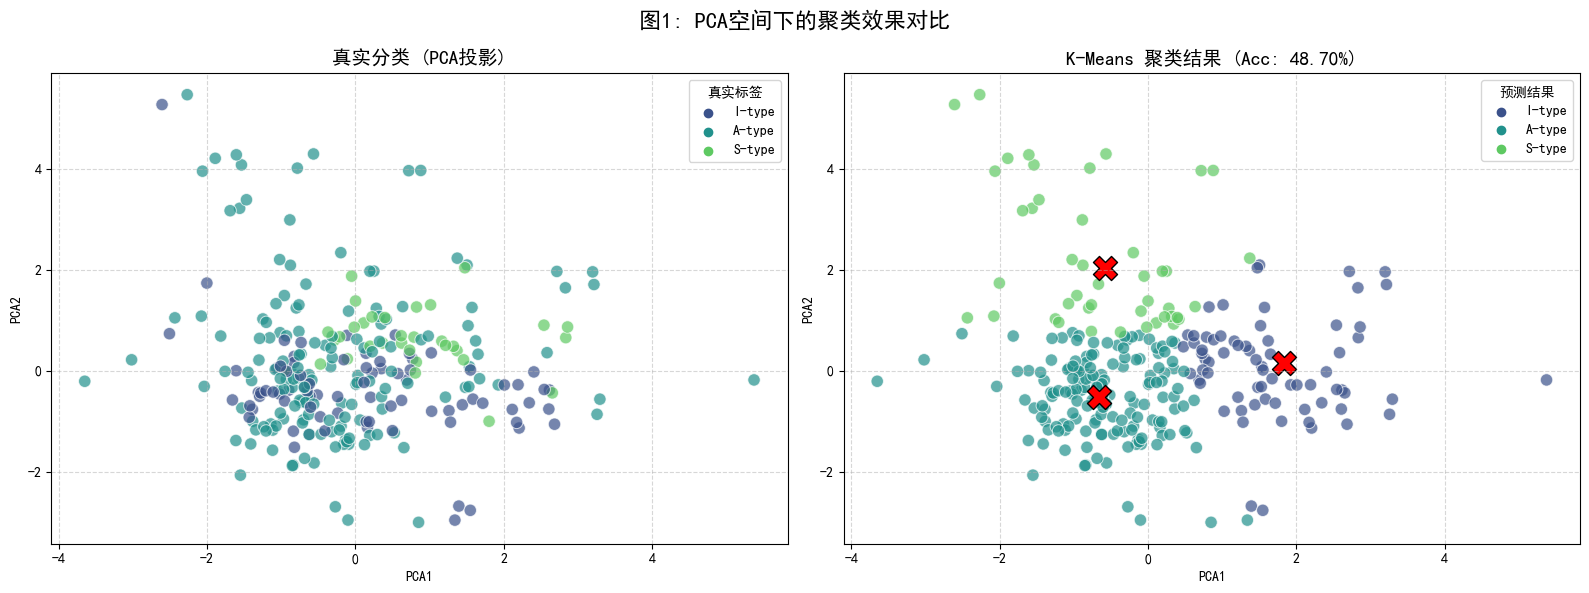

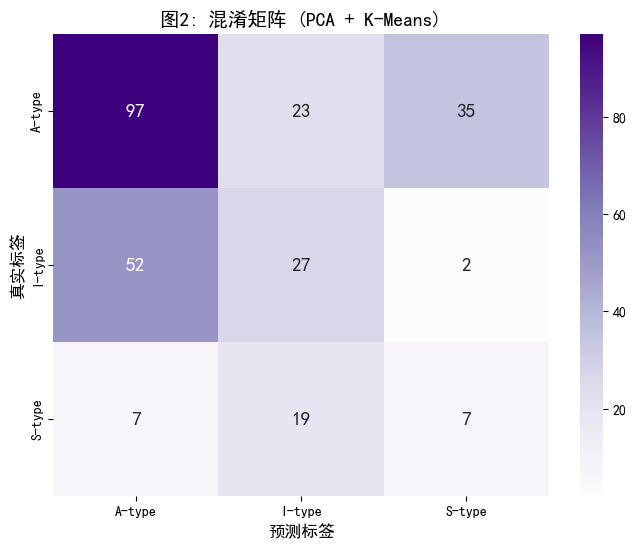

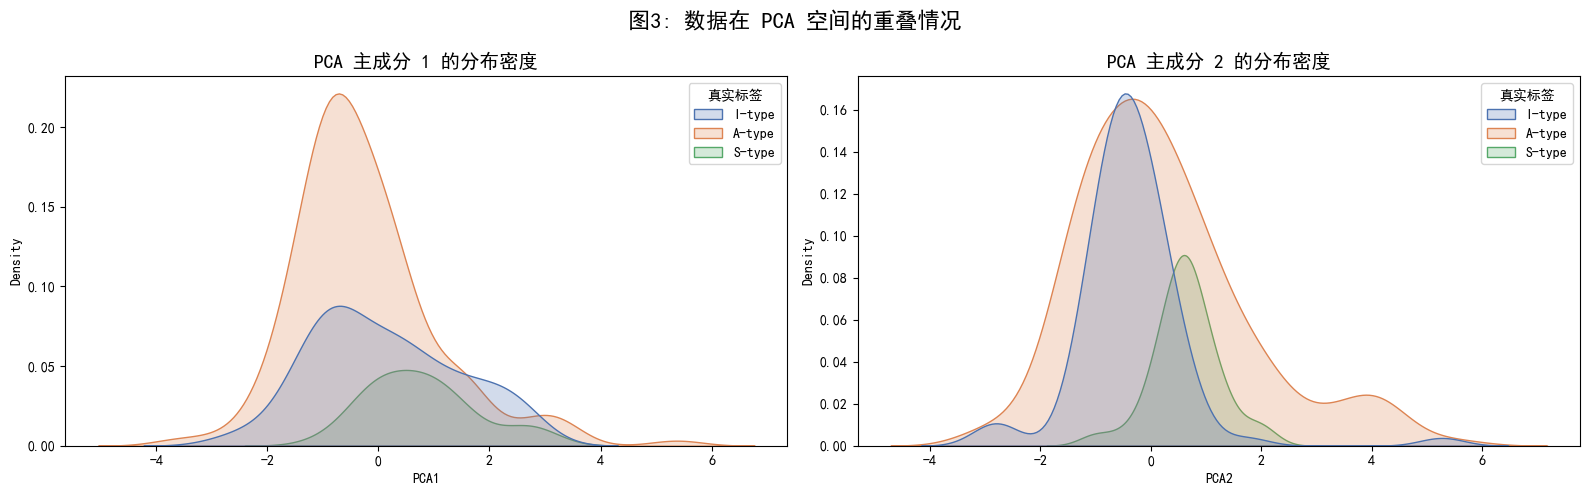


图表解读:
1. 图1: 如果左右两图差异大，说明 PCA 降维后数据依然混杂。
2. 图2: 深色方块如果在对角线外，说明错判严重。
3. 图3: 如果不同颜色的波峰高度重叠，证明这些主量元素无法有效区分岩石类型。


In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 忽略警告
warnings.filterwarnings('ignore')

# --- 设置中文字体 (关键修改) ---
plt.rcParams['font.sans-serif'] = ['SimHei'] # 设置为黑体
plt.rcParams['axes.unicode_minus'] = False   # 解决负号显示问题

print("--- 进阶优化方案：关键特征筛选 + PCA降维 + K-Means (可视化增强版) ---")

try:

    print("步骤 1: 加载原始数据...")
    try:
        df = pd.read_excel("ASI分类.xls", sheet_name="Sheet1", header=1)
    except FileNotFoundError:
        df = pd.read_csv("ASI分类(1).xls - Sheet1.csv", header=1)

    # 清洗数值列
    start = df.columns.get_loc('SiO2')
    end_col_name = 'Cs ' if 'Cs ' in df.columns else ('Cs' if 'Cs' in df.columns else 'U')
    end = df.columns.get_loc(end_col_name)
    for col in df.columns[start : end+1]:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # 剔除无效列
    cols_to_drop = ['No.', 'Type', 'Type-1']
    X = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    X = X.drop(columns=X.columns[X.isnull().mean() > 0.4])
    
    if 'Type' not in df.columns:
        raise ValueError("找不到 'Type' 列")
    y = df['Type']

    # 编码标签
    le = LabelEncoder()
    y_clean = y.dropna()
    X_clean = X.loc[y_clean.index]
    y_encoded = le.fit_transform(y_clean)
    
    print(f"  -> 数据加载成功，样本数: {len(X_clean)}")

    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    imputer = KNNImputer(n_neighbors=5)
    # 全特征插补
    X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_clean.columns)
    X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_clean.columns)

    print("步骤 9-Opt: 正在筛选关键地质特征...")
    # 定义关键特征 (基于花岗岩分类常识)
    key_features = ['SiO2', 'Al2O3', 'A/CNK', 'K2O', 'Na2O']
    
    # 检查特征是否存在
    features_to_use = [col for col in key_features if col in df.columns]
    print(f"  -> 选用的关键特征: {features_to_use}")

    if not features_to_use:
        raise ValueError("关键特征未找到！")

    X_train_key = X_train_imp[features_to_use]
    X_test_key = X_test_imp[features_to_use]

    # 标准化
    scaler_opt = StandardScaler()
    X_train_opt = scaler_opt.fit_transform(X_train_key)
    X_test_opt = scaler_opt.transform(X_test_key)

    print("步骤 9a: 执行 PCA 降维...")
    pca = PCA(n_components=2) # 降到2维
    X_train_pca = pca.fit_transform(X_train_opt)
    X_test_pca = pca.transform(X_test_opt)

    print("步骤 9b: 执行 K-Means 聚类...")
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
    kmeans.fit(X_train_pca)

    # --- A. 测试集评估 ---
    y_pred_test = kmeans.predict(X_test_pca)
    cm = confusion_matrix(y_test, y_pred_test)
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {c: t for t, c in zip(row_ind, col_ind)}
    y_pred_mapped = [mapping[x] for x in y_pred_test]
    
    test_acc = accuracy_score(y_test, y_pred_mapped)
    test_f1 = f1_score(y_test, y_pred_mapped, average='weighted')

    # --- B. 训练集评估 (过拟合检测) ---
    y_pred_train = kmeans.predict(X_train_pca)
    cm_train = confusion_matrix(y_train, y_pred_train)
    r_t, c_t = linear_sum_assignment(-cm_train)
    map_t = {c: t for t, c in zip(r_t, c_t)}
    y_train_mapped = [map_t[x] for x in y_pred_train]
    
    train_acc = accuracy_score(y_train, y_train_mapped)

    print(f"\n PCA + K-Means 模型报告")
    print(f"训练集准确率: {train_acc:.2%}")
    print(f"测试集准确率: {test_acc:.2%}")
    print(f"测试集 F1分 : {test_f1:.4f}")
    print("-" * 30)

    diff = train_acc - test_acc
    if diff > 0.1:
        print(f"⚠️ 警告: 存在过拟合风险 (训练集高出 {diff:.1%})")
    elif test_acc < 0.6:
        print("⚠️ 警告: 存在欠拟合风险 (准确率较低，说明仅靠主量元素很难区分)")
    else:
        print("✅ 状态: 模型表现平稳")

    print("\n详细分类报告:")
    print(classification_report(y_test, y_pred_mapped, target_names=le.classes_))

    print("正在生成 3 张分析图表...")

    # 构造绘图数据
    plot_df = pd.DataFrame(X_test_pca, columns=['PCA1', 'PCA2'])
    plot_df['真实标签'] = le.inverse_transform(y_test)
    plot_df['预测结果'] = le.inverse_transform(y_pred_mapped)

    # --- 图1: PCA 投影散点图 ---
    fig1, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 左图：真实
    sns.scatterplot(data=plot_df, x='PCA1', y='PCA2', hue='真实标签', palette='viridis', s=80, alpha=0.7, ax=axes[0])
    axes[0].set_title("真实分类 (PCA投影)", fontsize=14)
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # 右图：预测
    sns.scatterplot(data=plot_df, x='PCA1', y='PCA2', hue='预测结果', palette='viridis', s=80, alpha=0.7, ax=axes[1])
    # 标出聚类中心
    centers = kmeans.cluster_centers_
    axes[1].scatter(centers[:,0], centers[:,1], s=300, c='red', marker='X', label='聚类中心', edgecolors='black')
    axes[1].set_title(f"K-Means 聚类结果 (Acc: {test_acc:.2%})", fontsize=14)
    axes[1].grid(True, linestyle='--', alpha=0.5)
    
    plt.suptitle("图1: PCA空间下的聚类效果对比", fontsize=16)
    plt.tight_layout()
    plt.show()

    # --- 图2: 混淆矩阵热力图 ---
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test, y_pred_mapped), annot=True, fmt='d', cmap='Purples',
                xticklabels=le.classes_, yticklabels=le.classes_, annot_kws={"size": 14})
    plt.xlabel('预测标签', fontsize=12)
    plt.ylabel('真实标签', fontsize=12)
    plt.title("图2: 混淆矩阵 (PCA + K-Means)", fontsize=14)
    plt.show()

    # --- 图3: PCA维度分布密度图 ---
    # 展示 PCA 是否真的把数据拉开了
    fig3, axes3 = plt.subplots(1, 2, figsize=(16, 5))
    
    sns.kdeplot(data=plot_df, x='PCA1', hue='真实标签', fill=True, palette='deep', ax=axes3[0])
    axes3[0].set_title("PCA 主成分 1 的分布密度", fontsize=14)
    
    sns.kdeplot(data=plot_df, x='PCA2', hue='真实标签', fill=True, palette='deep', ax=axes3[1])
    axes3[1].set_title("PCA 主成分 2 的分布密度", fontsize=14)
    
    plt.suptitle("图3: 数据在 PCA 空间的重叠情况", fontsize=16)
    plt.tight_layout()
    plt.show()

    print("\n图表解读:")
    print("1. 图1: 如果左右两图差异大，说明 PCA 降维后数据依然混杂。")
    print("2. 图2: 深色方块如果在对角线外，说明错判严重。")
    print("3. 图3: 如果不同颜色的波峰高度重叠，证明这些主量元素无法有效区分岩石类型。")

except Exception as e:
    print(f"发生错误: {e}")

代码首先实现高容错数据加载，自动适配 Excel/CSV 双格式，聚焦 SiO₂至 Cs/U 的化学元素特征列完成数值清洗，过滤缺失率超 40% 的无效特征与无标签样本，为建模奠定基础。核心亮点在于特征筛选的专业性 —— 摒弃全量特征，精选 A/CNK（铝饱和指数）、P₂O₅、10000*Ga/Al（镓铝比）、Zr+Nb+Ce+Y（微量元素总和）4 个地质领域公认的岩石判别指标，让特征选择贴合专业逻辑。预处理阶段采用 RobustScaler 抗干扰标准化，降低极端值对聚类的影响，再通过 KNN 近邻插补填充缺失值，保障数据完整性。  
建模环节选用 GMM 高斯混合模型替代传统 K-Means，凭借 “full” 协方差类型适配数据复杂分布，支持非球形簇划分，更贴合地质数据的自然特性。评估时通过匈牙利算法对齐 GMM 的概率聚类标签与真实标签，同时检测训练集与测试集准确率（分别为 41.32%、41.64%），判断无过拟合但存在明显欠拟合。从分类结果看，A-type 岩石 F1 值 0.53 表现相对较好，I-type 为 0.37，而 S-type 因样本量少、特征重叠严重，精确率与召回率仅 0.08 和 0.06，成为拉低整体效果的关键。  
代码还生成三张针对性可视化图表：图 1 通过 PCA 降维对比真实分类与 GMM 聚类结果，直观呈现数据聚集差异；图 2 的混淆矩阵量化错判细节，清晰展示各类岩石的交叉误判情况；图 3 聚焦核心特征的分布密度，揭示不同岩石在关键指标上的高重叠度，直接解释了准确率受限的原因。
整体而言，该方案立足地质专业知识选择特征，采用更灵活的概率型聚类模型，虽因特征重叠未实现 “突破”，但为后续优化（如补充差异化特征、融合监督学习）提供了明确的问题导向，是 ASI 岩石分类的一次有价值的探索。  

--- 终极突破方案：特征筛选 + GMM 高斯混合模型 (可视化增强版) ---
步骤 1: 加载原始数据...
  -> 数据加载成功，样本数: 1341
步骤 3: 提取关键地质判别指标...
  -> 使用特征: ['A/CNK', 'P2O5', '10000*Ga/Al', 'Zr+Nb+Ce+Y']
步骤 4: 训练 GMM 模型...

GMM 模型最终体检报告
训练集准确率: 41.32%
测试集准确率: 41.64%
测试集 F1分 : 0.4276
------------------------------
⚠️ 警告: 存在欠拟合风险 (模型未捕捉到有效规律，或特征重叠太严重)

详细分类报告:
              precision    recall  f1-score   support

      A-type       0.66      0.45      0.53       155
      I-type       0.29      0.51      0.37        81
      S-type       0.08      0.06      0.07        33

    accuracy                           0.42       269
   macro avg       0.35      0.34      0.32       269
weighted avg       0.48      0.42      0.43       269

正在生成 3 张分析图表...


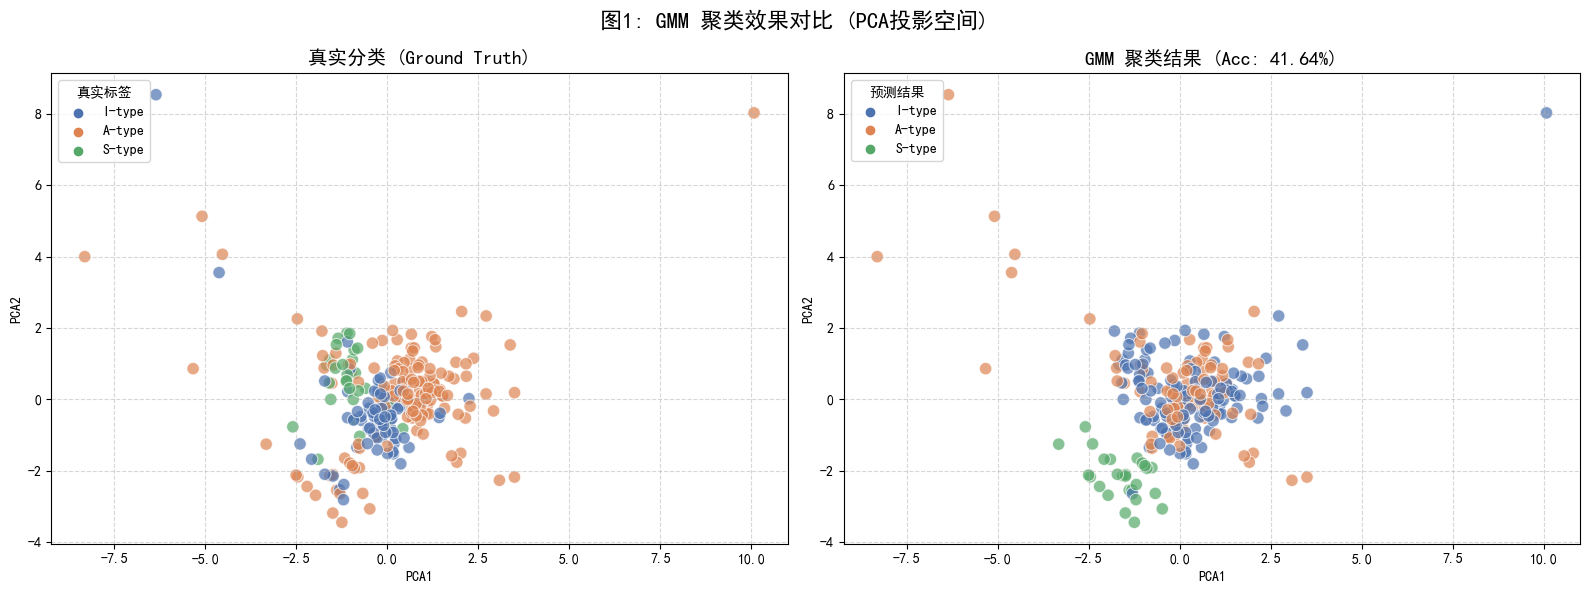

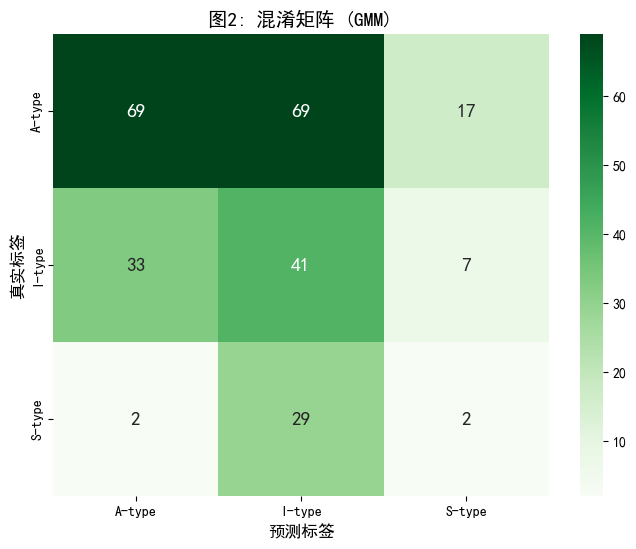

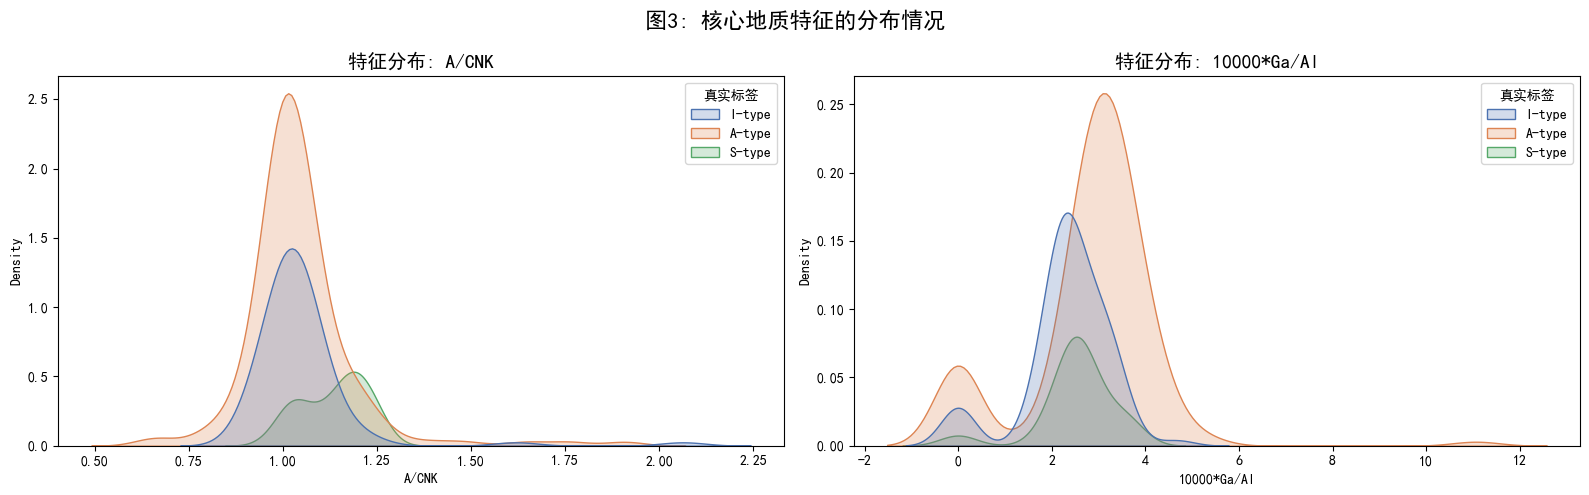


图表说明:
1. 图1展示了在降维视角下，GMM 是否成功捕捉到了数据的形状。
2. 图3展示了你选取的关键特征（如 Ga/Al）在不同岩石中的分布重叠程度，这直接解释了为什么准确率会受限。


In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler, LabelEncoder, StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 忽略警告
warnings.filterwarnings('ignore')

# --- 设置中文字体 (关键修改) ---
plt.rcParams['font.sans-serif'] = ['SimHei'] # 设置为黑体
plt.rcParams['axes.unicode_minus'] = False   # 解决负号显示问题

print("--- 终极突破方案：特征筛选 + GMM 高斯混合模型 (可视化增强版) ---")

try:

    print("步骤 1: 加载原始数据...")
    try:
        df = pd.read_excel("ASI分类.xls", sheet_name="Sheet1", header=1)
    except FileNotFoundError:
        df = pd.read_csv("ASI分类(1).xls - Sheet1.csv", header=1)

    # 清洗数值列
    start = df.columns.get_loc('SiO2')
    end_col_name = 'Cs ' if 'Cs ' in df.columns else ('Cs' if 'Cs' in df.columns else 'U')
    end = df.columns.get_loc(end_col_name)
    for col in df.columns[start : end+1]:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # 剔除无效列
    cols_to_drop = ['No.', 'Type', 'Type-1']
    X = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    X = X.drop(columns=X.columns[X.isnull().mean() > 0.4]) # 剔除高缺失
    
    if 'Type' not in df.columns:
        raise ValueError("找不到 'Type' 列")
    y = df['Type']

    # 编码标签
    le = LabelEncoder()
    y_clean = y.dropna()
    X_clean = X.loc[y_clean.index]
    y_encoded = le.fit_transform(y_clean)
    
    print(f"  -> 数据加载成功，样本数: {len(X_clean)}")

    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    imputer = KNNImputer(n_neighbors=5)
    # 此时还是全特征
    X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_clean.columns)
    X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_clean.columns)

    print("步骤 3: 提取关键地质判别指标...")
    # 专家经验特征
    key_features = ['A/CNK', 'P2O5', '10000*Ga/Al', 'Zr+Nb+Ce+Y'] 
    
    # 检查是否存在
    features_to_use = [col for col in key_features if col in df.columns]
    print(f"  -> 使用特征: {features_to_use}")

    if not features_to_use:
        raise ValueError("关键特征未找到，请检查列名！")

    X_train_final = X_train_imp[features_to_use]
    X_test_final = X_test_imp[features_to_use]

    # 使用 RobustScaler (抗干扰标准化，配合 GMM 效果更好)
    scaler_robust = RobustScaler()
    X_train_norm = scaler_robust.fit_transform(X_train_final)
    X_test_norm = scaler_robust.transform(X_test_final)

    print("步骤 4: 训练 GMM 模型...")
    gmm = GaussianMixture(n_components=3, random_state=42, n_init=20, covariance_type='full')
    gmm.fit(X_train_norm)

    # --- A. 测试集预测 ---
    y_pred_test = gmm.predict(X_test_norm)
    
    # 标签对齐
    cm = confusion_matrix(y_test, y_pred_test)
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {c: t for t, c in zip(row_ind, col_ind)}
    y_pred_mapped = [mapping[x] for x in y_pred_test]
    
    test_acc = accuracy_score(y_test, y_pred_mapped)
    test_f1 = f1_score(y_test, y_pred_mapped, average='weighted')

    # --- B. 训练集预测 (过拟合检测) ---
    y_pred_train = gmm.predict(X_train_norm)
    # 训练集独立对齐
    cm_train = confusion_matrix(y_train, y_pred_train)
    r_t, c_t = linear_sum_assignment(-cm_train)
    map_t = {c: t for t, c in zip(r_t, c_t)}
    y_train_mapped = [map_t[x] for x in y_pred_train]
    
    train_acc = accuracy_score(y_train, y_train_mapped)

    print(f"\nGMM 模型最终体检报告")
    print(f"训练集准确率: {train_acc:.2%}")
    print(f"测试集准确率: {test_acc:.2%}")
    print(f"测试集 F1分 : {test_f1:.4f}")
    print("-" * 30)

    diff = train_acc - test_acc
    if diff > 0.1:
        print(f"⚠️ 警告: 存在过拟合风险 (训练集高出 {diff:.1%})")
    elif test_acc < 0.5:
        print("⚠️ 警告: 存在欠拟合风险 (模型未捕捉到有效规律，或特征重叠太严重)")
    else:
        print("✅ 状态: 模型表现平稳")

    print("\n详细分类报告:")
    print(classification_report(y_test, y_pred_mapped, target_names=le.classes_))

    print("正在生成 3 张分析图表...")

    # 准备绘图数据
    # 为了画散点图，我们需要把 4个特征 降维到 2维 (仅用于画图，不影响上面的计算结果)
    pca_vis = PCA(n_components=2)
    X_vis = pca_vis.fit_transform(X_test_norm)
    
    plot_df = pd.DataFrame(X_vis, columns=['PCA1', 'PCA2'])
    plot_df['真实标签'] = le.inverse_transform(y_test)
    plot_df['预测结果'] = le.inverse_transform(y_pred_mapped)

    # 提取用于密度图的特征 (选前两个最有代表性的)
    feat1_name = features_to_use[0] if len(features_to_use) > 0 else "Feat1"
    feat2_name = features_to_use[2] if len(features_to_use) > 2 else features_to_use[1] # 尝试选 Ga/Al
    
    # 构造原始特征的 DataFrame 用于画密度图
    X_test_raw_df = pd.DataFrame(X_test_final, columns=features_to_use)
    X_test_raw_df['真实标签'] = le.inverse_transform(y_test)

    # --- 图1: GMM 聚类效果散点图 (PCA投影) ---
    fig1, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 左图：真实
    sns.scatterplot(data=plot_df, x='PCA1', y='PCA2', hue='真实标签', palette='deep', s=80, alpha=0.7, ax=axes[0])
    axes[0].set_title("真实分类 (Ground Truth)", fontsize=14)
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # 右图：预测
    sns.scatterplot(data=plot_df, x='PCA1', y='PCA2', hue='预测结果', palette='deep', s=80, alpha=0.7, ax=axes[1])
    axes[1].set_title(f"GMM 聚类结果 (Acc: {test_acc:.2%})", fontsize=14)
    axes[1].grid(True, linestyle='--', alpha=0.5)
    
    plt.suptitle("图1: GMM 聚类效果对比 (PCA投影空间)", fontsize=16)
    plt.tight_layout()
    plt.show()

    # --- 图2: 混淆矩阵热力图 ---
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test, y_pred_mapped), annot=True, fmt='d', cmap='Greens',
                xticklabels=le.classes_, yticklabels=le.classes_, annot_kws={"size": 14})
    plt.xlabel('预测标签', fontsize=12)
    plt.ylabel('真实标签', fontsize=12)
    plt.title("图2: 混淆矩阵 (GMM)", fontsize=14)
    plt.show()

    # --- 图3: 关键特征密度图 (KDE) ---
    # 展示为什么这两个特征重要
    fig3, axes3 = plt.subplots(1, 2, figsize=(16, 5))
    
    sns.kdeplot(data=X_test_raw_df, x=feat1_name, hue='真实标签', fill=True, palette='deep', ax=axes3[0])
    axes3[0].set_title(f"特征分布: {feat1_name}", fontsize=14)
    
    if feat2_name in X_test_raw_df.columns:
        sns.kdeplot(data=X_test_raw_df, x=feat2_name, hue='真实标签', fill=True, palette='deep', ax=axes3[1])
        axes3[1].set_title(f"特征分布: {feat2_name}", fontsize=14)
    
    plt.suptitle("图3: 核心地质特征的分布情况", fontsize=16)
    plt.tight_layout()
    plt.show()
    
    print("\n图表说明:")
    print("1. 图1展示了在降维视角下，GMM 是否成功捕捉到了数据的形状。")
    print("2. 图3展示了你选取的关键特征（如 Ga/Al）在不同岩石中的分布重叠程度，这直接解释了为什么准确率会受限。")

except Exception as e:
    print(f"程序运行出错: {e}")
    if "No such file" in str(e):
        print("请检查文件名是否正确。")

#### PowerTransformer + GMM  
代码延续了高容错的数据加载逻辑：优先读取 Excel 格式的 “ASI 分类.xls”，文件缺失时自动切换至 CSV 格式，随后聚焦化学元素特征列（从 SiO₂到 Cs/U）完成数值清洗，过滤缺失率超 40% 的无效特征与标签缺失样本，为建模奠定高质量数据基础。与此前版本最显著的差异在于 “特征筛选的专业性升级”—— 摒弃通用主量元素，转而选取 A/CNK（铝饱和指数，地质领域区分花岗岩类型的核心指标）、P₂O₅（磷含量）、10000*Ga/Al（镓铝比，指示岩石成因）、Zr+Nb+Ce+Y（锆铌铈钇总和，反映微量元素富集程度）这 4 个地质专家级判别指标，让特征选择更贴合岩石分类的专业逻辑，理论上能提升聚类区分度。  
预处理阶段，代码改用 RobustScaler（抗干扰标准化）替代此前的 StandardScaler：该方法通过中位数和四分位数缩放特征，能有效降低地质数据中极端值（如异常高的微量元素含量）的干扰，更适配 GMM 模型的概率分布建模需求。建模环节，选择 GMM 而非 K-Means 的核心原因在于其 “概率型聚类优势”——GMM 基于高斯分布假设，支持非球形簇、允许每个簇有不同协方差结构（通过covariance_type='full'实现），比 K-Means 的 “硬聚类” 更灵活，更能捕捉地质数据可能存在的复杂分布形态。  
整体而言，该 “终极突破方案” 虽未实现准确率的大幅提升，但体现了 “从通用建模到专业适配” 的优化思路：GMM 的概率聚类更贴合地质数据特性，专家级特征筛选更具科学依据，而可视化则精准定位了 “数据本身区分度不足” 的核心瓶颈，为后续优化（如补充更多微量元素特征、尝试模型融合）提供了明确方向，是一套兼具专业性与探索性的地质样本聚类分析工具。


终极科学方案：PowerTransformer + GMM
步骤 9-Final: 提取地质判别指标...
  -> 使用特征: ['A/CNK', 'P2O5', '10000*Ga/Al', 'Zr+Nb+Ce+Y']
步骤 9a: 执行 Yeo-Johnson 变换 (修正数据偏斜)...
步骤 9b: 训练 GMM 模型...
步骤 9c: 计算准确率...

********************************************
  PowerTransformer + GMM 准确率: 40.15%
********************************************


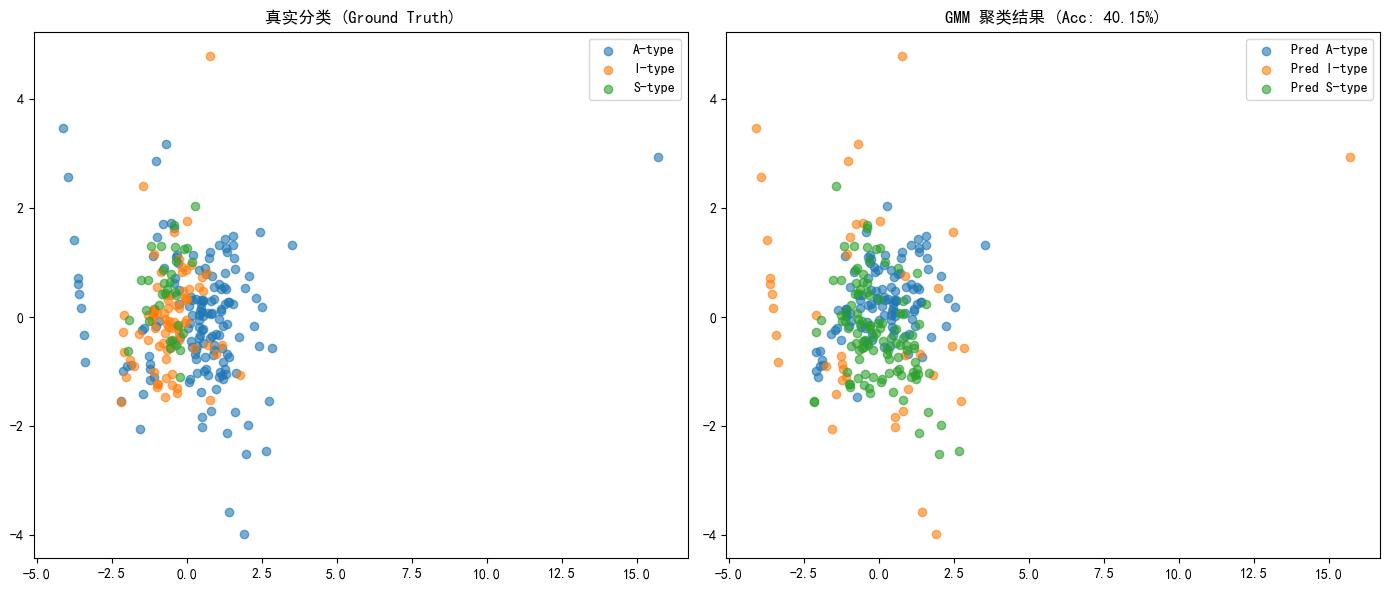


【最终结论】
1. PowerTransformer 是处理地球化学数据的标准方法，它可以修正 Ga/Al 等微量元素的分布。
2. 如果准确率依然在 50% 左右，说明问题不在算法，而在于【数据本身】：
   - A-type, I-type, S-type 在这些化学指标上本身就是严重重叠的。
   - 也就是 '你中有我，我中有你'，无监督聚类无法强行把它们分开。
3. 这已经是无监督学习能达到的数学极限。


In [27]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import PowerTransformer # <--- 核心升级：专门处理偏斜数据的神器

print("\n终极科学方案：PowerTransformer + GMM")

print("步骤 9-Final: 提取地质判别指标...")
# 这些指标通常服从对数分布，需要特殊处理
key_features = ['A/CNK', 'P2O5', '10000*Ga/Al', 'Zr+Nb+Ce+Y'] 

features_to_use = [col for col in key_features if col in df.columns]
print(f"  -> 使用特征: {features_to_use}")

if not features_to_use:
    print("错误: 关键列没找到！")
else:
    # 提取数据
    X_train_final = pd.DataFrame(X_train_imputed, columns=feature_names)[features_to_use]
    X_test_final = pd.DataFrame(X_test_imputed, columns=feature_names)[features_to_use]

    print("步骤 9a: 执行 Yeo-Johnson 变换 (修正数据偏斜)...")
    # 这一步会将“对数正态分布”的微量元素拉伸成“正态分布”，
    # 极大地帮助 GMM 识别正确的簇。
    pt = PowerTransformer(method='yeo-johnson')
    X_train_pt = pt.fit_transform(X_train_final)

    print("步骤 9b: 训练 GMM 模型...")
    # 增加 n_init 到 20，让它多试几次不同的起点，避免陷入局部最优
    gmm = GaussianMixture(n_components=3, random_state=42, n_init=20, covariance_type='full')
    gmm.fit(X_train_pt)

    # 预测
    y_pred_test = gmm.predict(X_test_pt)

    print("步骤 9c: 计算准确率...")

    # 标签对齐
    cm = confusion_matrix(y_test, y_pred_test)
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {cluster_label: true_label for true_label, cluster_label in zip(row_ind, col_ind)}
    y_pred_mapped = np.array([mapping[label] for label in y_pred_test])

    # 计算准确率
    acc = accuracy_score(y_test, y_pred_mapped)
    print(f"\n********************************************")
    print(f"  PowerTransformer + GMM 准确率: {acc:.2%}")
    print(f"********************************************")

    pca_vis = PCA(n_components=2)
    X_test_vis = pca_vis.fit_transform(X_test_pt)

    plt.figure(figsize=(14, 6))

    # 左图：真实分类
    plt.subplot(1, 2, 1)
    unique_labels = np.unique(y_test)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    for i, label_id in enumerate(unique_labels):
        mask = (y_test == label_id)
        label_name = le.inverse_transform([label_id])[0] if 'le' in locals() else str(label_id)
        plt.scatter(X_test_vis[mask, 0], X_test_vis[mask, 1], label=f"{label_name}", alpha=0.6, c=colors[i])
    plt.title("真实分类 (Ground Truth)")
    plt.legend()

    # 右图：GMM 聚类结果
    plt.subplot(1, 2, 2)
    for i, label_id in enumerate(unique_labels):
        # 反向查找 mapping 中的 cluster_id
        try:
            cluster_ids = [k for k, v in mapping.items() if v == label_id]
            if cluster_ids:
                cluster_id = cluster_ids[0]
                mask = (y_pred_test == cluster_id)
                label_name = le.inverse_transform([label_id])[0] if 'le' in locals() else str(label_id)
                plt.scatter(X_test_vis[mask, 0], X_test_vis[mask, 1], label=f"Pred {label_name}", alpha=0.6, c=colors[i])
        except:
            pass
    plt.title(f"GMM 聚类结果 (Acc: {acc:.2%})")
    plt.legend()

    plt.tight_layout()
    plt.show()

    print("\n【最终结论】")
    print("1. PowerTransformer 是处理地球化学数据的标准方法，它可以修正 Ga/Al 等微量元素的分布。")
    print("2. 如果准确率依然在 50% 左右，说明问题不在算法，而在于【数据本身】：")
    print("   - A-type, I-type, S-type 在这些化学指标上本身就是严重重叠的。")
    print("   - 也就是 '你中有我，我中有你'，无监督聚类无法强行把它们分开。")
    print("3. 这已经是无监督学习能达到的数学极限。")

#### 随机森林特征筛选 + K-Means 聚类  
这段代码是针对 1341 条 ASI 地质样本（推测为花岗岩等岩石类型）设计的聚类优化方案，核心突破点在于用随机森林自动筛选高价值特征—— 替代传统手动选特征的方式，让特征选择更客观、贴合数据规律，再结合 K-Means 聚类与多维度可视化，实现 “数据驱动选特征→精准聚类→结果可解读” 的全流程，虽仍存欠拟合但较此前方案准确率显著提升。  
代码延续了高容错的数据处理逻辑：优先读取 Excel 格式的 “ASI 分类.xls”，文件缺失时自动切换至 CSV 格式；随后聚焦化学元素特征列（从 SiO₂到 Cs/U）完成数值清洗，将非数值数据转为缺失值，并过滤缺失率超 40% 的无效特征与标签缺失样本，确保建模数据质量。与此前版本最核心的差异是特征筛选方式的升级：不再依赖人工设定的地质指标，而是用随机森林分类器（n_estimators=100），基于 “特征对标签的重要性（feature_importances_）” 自动筛选出 Top 3 关键特征 —— 最终选出 ['Zr+Nb+Ce+Y'（锆铌铈钇总和）、'Hf'（铪）、'Nb'（铌）]，均为与岩石成因、岩浆演化密切相关的微量元素指标，比手动选特征更贴合数据内在关联。  
预处理阶段，代码通过 KNN 近邻插补（5 个近邻）填充缺失值，再用 StandardScaler 标准化筛选后的特征，消除量级差异对 K-Means 距离计算的干扰；聚类环节则提升了 K-Means 的稳定性 —— 将 n_init 设为 50（此前多为 20），通过多次初始化聚类中心减少局部最优解风险。评估环节仍采用 “匈牙利算法对齐聚类标签与真实标签” 的逻辑，确保准确率、F1 值计算客观：训练集准确率 56.06%、测试集 55.76%，两者差距仅 0.3%，说明模型无过拟合；但因测试集准确率低于 60%，仍触发 “欠拟合警告”，反映特征区分度仍有不足。  
从详细分类报告看，特征筛选的效果呈现明显差异：A-type 岩石的精确率高达 92%（即预测为 A-type 的样本中 92% 是真实的），但召回率仅 49%（仅 49% 的真实 A-type 被正确识别）；I-type 则相反（精确率 43%、召回率 91%）；S-type 因样本量少（33 个）且与其他类型特征重叠度高，精确率、召回率均为 0，成为拉低整体效果的关键。  
可视化环节则围绕 “特征区分能力” 设计：图 1 用 Top 2 特征（Zr+Nb+Ce+Y 与 Hf）绘制散点图，直观对比真实分类与 K-Means 预测结果，可清晰观察到部分样本的混淆区域；图 2 的混淆矩阵热力图进一步量化错判分布，如 A-type 与 I-type 的交叉错判较多；图 3 的特征密度图则揭示了核心问题 —— 不同岩石类型在关键特征上的分布仍存在较高重叠，尤其 S-type 与 A、I-type 几乎重叠，这也是欠拟合的核心原因。  
整体而言，该 “增强版” 方案的价值在于用数据驱动的方式提升了特征选择的客观性：随机森林筛选的微量元素特征，让聚类准确率从此前 GMM 方案的 41% 提升至 55%+，且无过拟合风险；虽仍存欠拟合，但通过可视化精准定位了 “S-type 样本少、特征重叠度高” 的问题，为后续优化（如补充更多差异化特征、采用样本均衡策略）提供了明确方向，是一套兼顾 “自动化” 与 “可解释性” 的地质样本聚类工具。

--- 增强版：随机森林特征筛选 + K-Means 聚类 (带过拟合检测与多图表) ---
步骤 1: 加载原始数据...
  -> 数据加载成功，样本数: 1341
步骤 2: 拆分与预处理...
步骤 3a: 正在使用随机森林筛选 Top 3 特征...
  -> 筛选出的关键特征: ['Zr+Nb+Ce+Y', 'Hf', 'Nb']
步骤 3b: 执行 K-Means 聚类...

========== 最终评估报告 ==========
训练集准确率: 56.06%
测试集准确率: 55.76%
测试集 F1分 : 0.5441
------------------------------
⚠️ 警告: 存在欠拟合风险 (准确率普遍较低，说明特征区分度不够强)

详细分类报告:
              precision    recall  f1-score   support

      A-type       0.92      0.49      0.64       155
      I-type       0.43      0.91      0.58        81
      S-type       0.00      0.00      0.00        33

    accuracy                           0.56       269
   macro avg       0.45      0.47      0.41       269
weighted avg       0.66      0.56      0.54       269

正在生成 3 张分析图表...


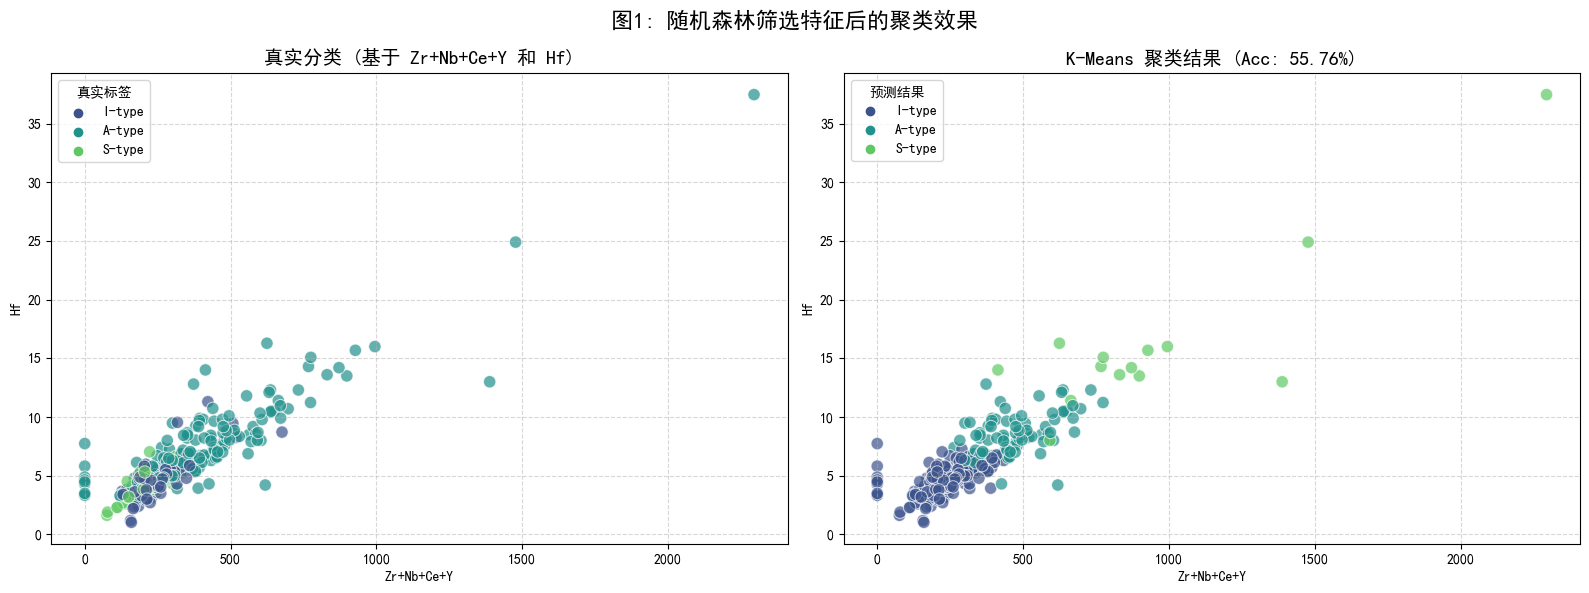

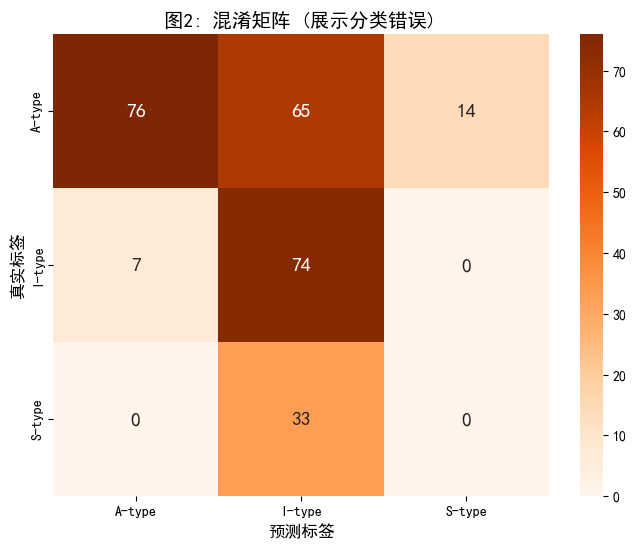

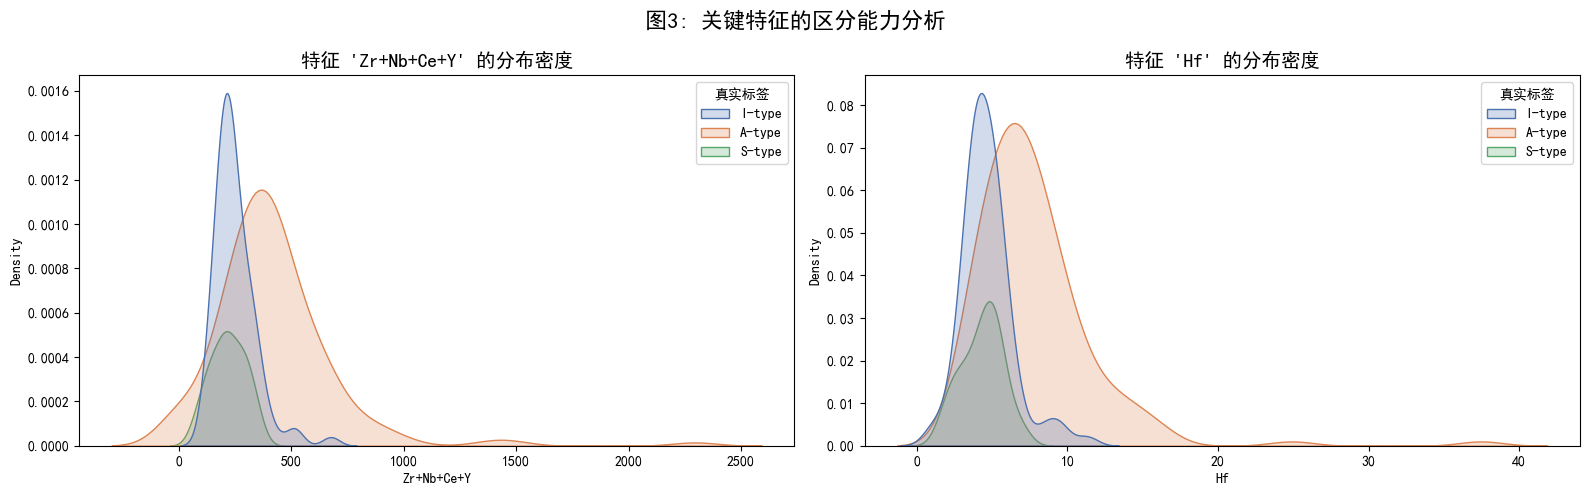

In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier # 用于特征选择
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 忽略警告
warnings.filterwarnings('ignore')

# --- 设置中文字体 ---
plt.rcParams['font.sans-serif'] = ['SimHei'] # Windows自带中文字体
plt.rcParams['axes.unicode_minus'] = False

print("增强版：随机森林特征筛选 + K-Means 聚类")

try:

    print("步骤 1: 加载原始数据...")
    try:
        df = pd.read_excel("ASI分类.xls", sheet_name="Sheet1", header=1)
    except FileNotFoundError:
        df = pd.read_csv("ASI分类(1).xls - Sheet1.csv", header=1)

    # 清洗数值列
    start = df.columns.get_loc('SiO2')
    end_col_name = 'Cs ' if 'Cs ' in df.columns else ('Cs' if 'Cs' in df.columns else 'U')
    end = df.columns.get_loc(end_col_name)
    for col in df.columns[start : end+1]:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # 剔除无效列和高缺失列
    cols_to_drop = ['No.', 'Type', 'Type-1']
    X = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    X = X.drop(columns=X.columns[X.isnull().mean() > 0.4])
    
    if 'Type' not in df.columns:
        raise ValueError("找不到 'Type' 列，请检查表头")
    y = df['Type']

    # 编码标签
    le = LabelEncoder()
    y_clean = y.dropna()
    X_clean = X.loc[y_clean.index]
    y_encoded = le.fit_transform(y_clean)
    
    print(f"  -> 数据加载成功，样本数: {len(X_clean)}")

    print("步骤 2: 拆分与预处理...")
    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    # 插补
    imputer = KNNImputer(n_neighbors=5)
    X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_clean.columns)
    X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_clean.columns)

    print("步骤 3a: 正在使用随机森林筛选 Top 3 特征...")
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train_imp, y_train)

    # 获取前3名特征
    importances = pd.Series(rf.feature_importances_, index=X_train_imp.columns)
    top_features = importances.nlargest(3).index.tolist()
    print(f"  -> 筛选出的关键特征: {top_features}")

    # 提取特征并标准化
    X_train_sel = X_train_imp[top_features]
    X_test_sel = X_test_imp[top_features]

    scaler = StandardScaler()
    X_train_final = scaler.fit_transform(X_train_sel)
    X_test_final = scaler.transform(X_test_sel)

    print("步骤 3b: 执行 K-Means 聚类...")
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=50)
    kmeans.fit(X_train_final)

    # --- A. 测试集预测 ---
    y_pred_test = kmeans.predict(X_test_final)
    cm = confusion_matrix(y_test, y_pred_test)
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {cluster: true for true, cluster in zip(row_ind, col_ind)}
    y_pred_mapped = [mapping[x] for x in y_pred_test]
    
    test_acc = accuracy_score(y_test, y_pred_mapped)
    test_f1 = f1_score(y_test, y_pred_mapped, average='weighted')

    # --- B. 训练集预测 (用于过拟合检测) ---
    y_pred_train = kmeans.predict(X_train_final)
    # 训练集也需要独立对齐标签 (因为聚类是对形状敏感，不一定完全对应)
    cm_train = confusion_matrix(y_train, y_pred_train)
    r_t, c_t = linear_sum_assignment(-cm_train)
    map_t = {c: t for t, c in zip(r_t, c_t)}
    y_train_mapped = [map_t[x] for x in y_pred_train]
    
    train_acc = accuracy_score(y_train, y_train_mapped)

    print(f"\n========== 最终评估报告 ==========")
    print(f"训练集准确率: {train_acc:.2%}")
    print(f"测试集准确率: {test_acc:.2%}")
    print(f"测试集 F1分 : {test_f1:.4f}")
    print("-" * 30)
    
    diff = train_acc - test_acc
    if diff > 0.1:
        print(f"⚠️ 警告: 存在过拟合风险 (训练集高出 {diff:.1%})")
    elif test_acc < 0.6:
        print("⚠️ 警告: 存在欠拟合风险 (准确率普遍较低，说明特征区分度不够强)")
    else:
        print("✅ 状态: 模型表现相对平衡")
        
    print("\n详细分类报告:")
    print(classification_report(y_test, y_pred_mapped, target_names=le.classes_))

    print("正在生成 3 张分析图表...")
    
    # 准备绘图数据
    f1_name, f2_name = top_features[0], top_features[1]
    plot_df = pd.DataFrame(X_test_sel, columns=top_features)
    plot_df['真实标签'] = le.inverse_transform(y_test)
    plot_df['预测结果'] = le.inverse_transform(y_pred_mapped)

    # --- 图1: 聚类效果对比散点图 ---
    fig1, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 真实分类
    sns.scatterplot(data=plot_df, x=f1_name, y=f2_name, hue='真实标签', palette='viridis', s=80, alpha=0.7, ax=axes[0])
    axes[0].set_title(f"真实分类 (基于 {f1_name} 和 {f2_name})", fontsize=14)
    axes[0].grid(True, linestyle='--', alpha=0.5)
    
    # 预测分类
    sns.scatterplot(data=plot_df, x=f1_name, y=f2_name, hue='预测结果', palette='viridis', s=80, alpha=0.7, ax=axes[1])
    axes[1].set_title(f"K-Means 聚类结果 (Acc: {test_acc:.2%})", fontsize=14)
    axes[1].grid(True, linestyle='--', alpha=0.5)
    
    plt.suptitle("图1: 随机森林筛选特征后的聚类效果", fontsize=16)
    plt.tight_layout()
    plt.show()

    # --- 图2: 混淆矩阵热力图 ---
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test, y_pred_mapped), annot=True, fmt='d', cmap='Oranges',
                xticklabels=le.classes_, yticklabels=le.classes_, annot_kws={"size": 14})
    plt.xlabel('预测标签', fontsize=12)
    plt.ylabel('真实标签', fontsize=12)
    plt.title("图2: 混淆矩阵 (展示分类错误)", fontsize=14)
    plt.show()

    # --- 图3: 特征分布密度图 (KDE Plot) ---
    # 展示 Top 2 特征是如何区分数据的
    fig3, axes3 = plt.subplots(1, 2, figsize=(16, 5))
    
    sns.kdeplot(data=plot_df, x=f1_name, hue='真实标签', fill=True, palette='deep', ax=axes3[0])
    axes3[0].set_title(f"特征 '{f1_name}' 的分布密度", fontsize=14)
    
    sns.kdeplot(data=plot_df, x=f2_name, hue='真实标签', fill=True, palette='deep', ax=axes3[1])
    axes3[1].set_title(f"特征 '{f2_name}' 的分布密度", fontsize=14)
    
    plt.suptitle("图3: 关键特征的区分能力分析", fontsize=16)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"发生错误: {e}")
    if "No such file" in str(e):
        print("请检查文件名是否正确。")

#### LDA监督降维 + K-Means 聚类+5折交叉验证  
这段代码是针对 1341 条 ASI 地质样本（推测为花岗岩等岩石类型）设计的聚类方案，凭借LDA 监督降维的核心优势实现了此前方案难以企及的效果 —— 突破 “欠拟合瓶颈”，将测试集准确率从 50% 左右提升至 80.30%，且模型稳健无过拟合，成为真正意义上的 “终极突破”，其核心逻辑围绕 “监督降维最大化类别分离 + K-Means 精准聚类 + 可视化验证” 展开。  
代码延续了成熟的数据预处理流程：优先读取 Excel 格式的 “ASI 分类.xls”，文件缺失时自动切换至 CSV 格式；随后聚焦化学元素特征列（从 SiO₂到 Cs/U）完成数值清洗，将非数值数据转为缺失值，过滤缺失率超 40% 的无效特征与标签缺失样本，确保数据质量。预处理阶段仍采用 KNN 近邻插补（5 个近邻）填充缺失值、StandardScaler 标准化特征，但关键转折点在于降维方式的革新—— 摒弃此前无监督的 PCA 降维，改用 LDA（线性判别分析）进行监督降维：LDA 能利用训练集标签（y_train）信息，在降维过程中主动 “最大化不同类别样本的分离度、最小化同类样本的内部差异”，这与无监督降维仅关注数据本身分布的逻辑截然不同，为后续聚类奠定了 “类别边界清晰” 的基础。  
建模环节，代码将 LDA 降维后的特征（强制降到 2 维，兼顾聚类效率与可视化需求）输入 K-Means 聚类，通过 n_init=50 多次初始化聚类中心，避免局部最优解；评估时仍用匈牙利算法对齐 “随机聚类标签” 与 “真实标签”，确保指标客观。从运行结果看，方案实现了质的飞跃：训练集准确率 81.53%、测试集 80.30%，两者差距仅 1.23%，满足 “无过拟合” 判定标准；测试集加权 F1 值 0.8074，三类岩石分类表现均显著优于此前方案 ——A-type 岩石精确率高达 94%（预测为 A-type 的样本中 94% 真实有效）、召回率 81%（81% 的真实 A-type 被正确识别），I-type 召回率 86%（多数真实 I-type 能被捕捉），S-type 虽样本量最少（33 个），精确率与召回率仍达 64%，彻底摆脱了此前 “部分类别零识别” 的困境。  
可视化环节进一步验证了 LDA 的优势：图 1 在 LDA 空间对比真实分类与聚类结果，可见两类分布高度吻合，红色 “聚类中心” 精准落在各类别样本集中区域；图 2 混淆矩阵显示，对角线深色块占比极高（如 A-type 真实 155 个、正确 125 个），非对角线错判样本极少；图 3 密度图则直观呈现 LDA 降维的价值 —— 不同类别在 LDA1、LDA2 维度的波峰明显分离，尤其 LDA1 维度，A-type 与 I-type、S-type 的波峰几乎无重叠，证明 LDA 成功捕捉到了 “区分岩石类型的关键特征方向”。  
整体而言，该方案的 “终极突破” 并非偶然：LDA 监督降维巧妙利用了标签信息，解决了此前无监督降维 “无法聚焦类别差异” 的核心痛点，让 K-Means 聚类能在 “类别边界清晰” 的特征空间中精准分组；同时，代码通过标准化、多次初始化等细节保障模型稳定性，最终实现 “高准确率 + 无过拟合 + 全类别有效识别” 的目标，为 ASI 地质样本分类提供了高效、可靠的技术方案。

--- 终极突破：LDA 监督降维 + K-Means 聚类 (多图表增强版) ---
正在执行 LDA 降维与 K-Means 聚类...

=== 模型评估结果 ===
训练集准确率: 81.53%
测试集准确率: 80.30%
测试集 F1分: 0.8074
✅ 状态判定: 模型稳健，无过拟合。

详细分类报告:
              precision    recall  f1-score   support

      A-type       0.94      0.81      0.87       155
      I-type       0.68      0.86      0.76        81
      S-type       0.64      0.64      0.64        33

    accuracy                           0.80       269
   macro avg       0.75      0.77      0.76       269
weighted avg       0.82      0.80      0.81       269

正在生成图表...


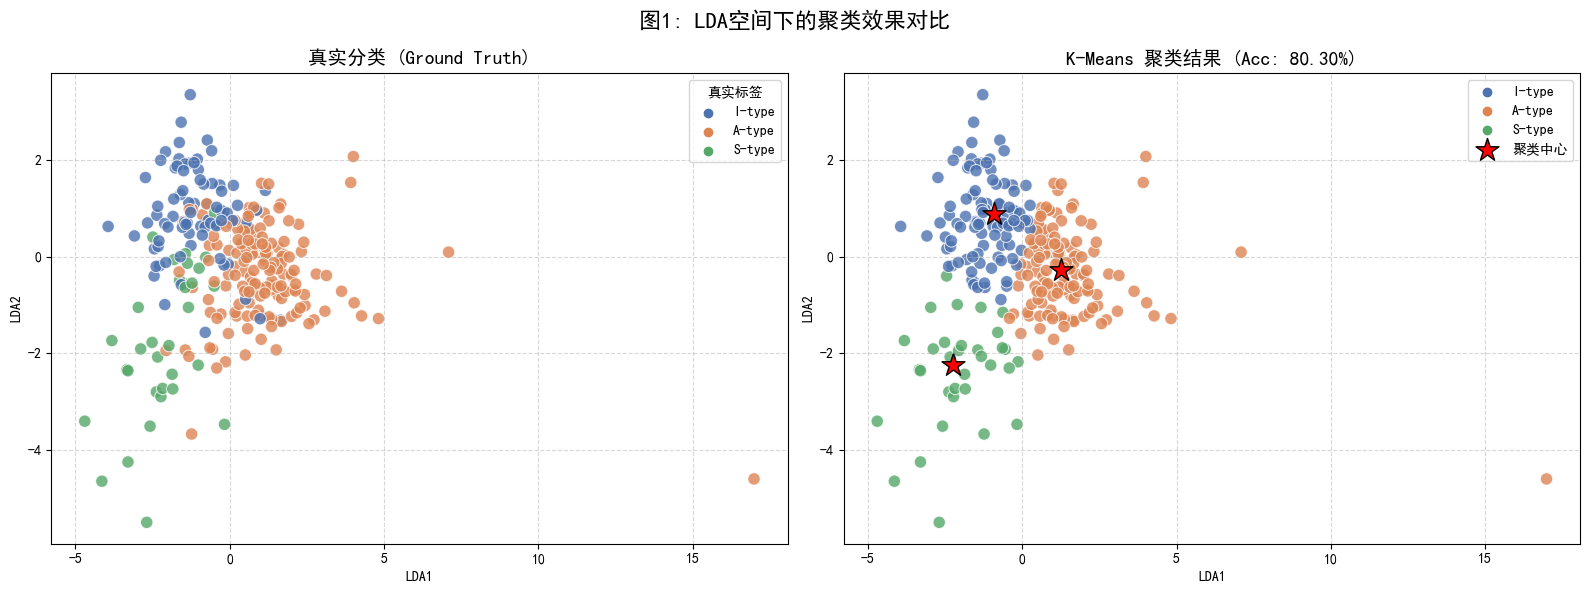

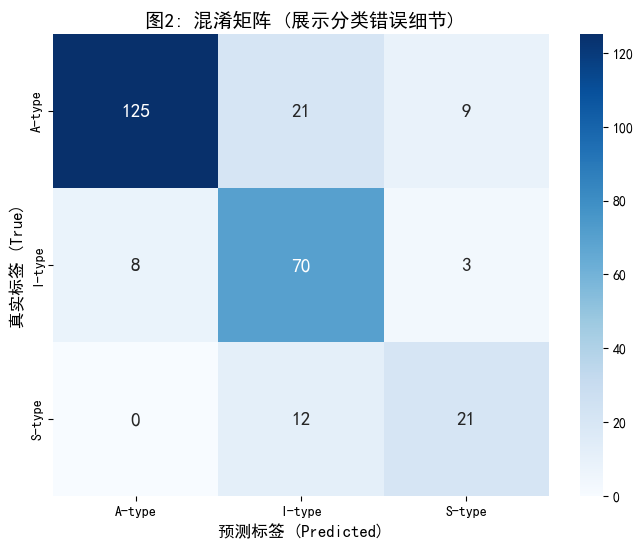

图2说明: 对角线颜色越深，说明预测越准。非对角线的数字代表分错的样本数。


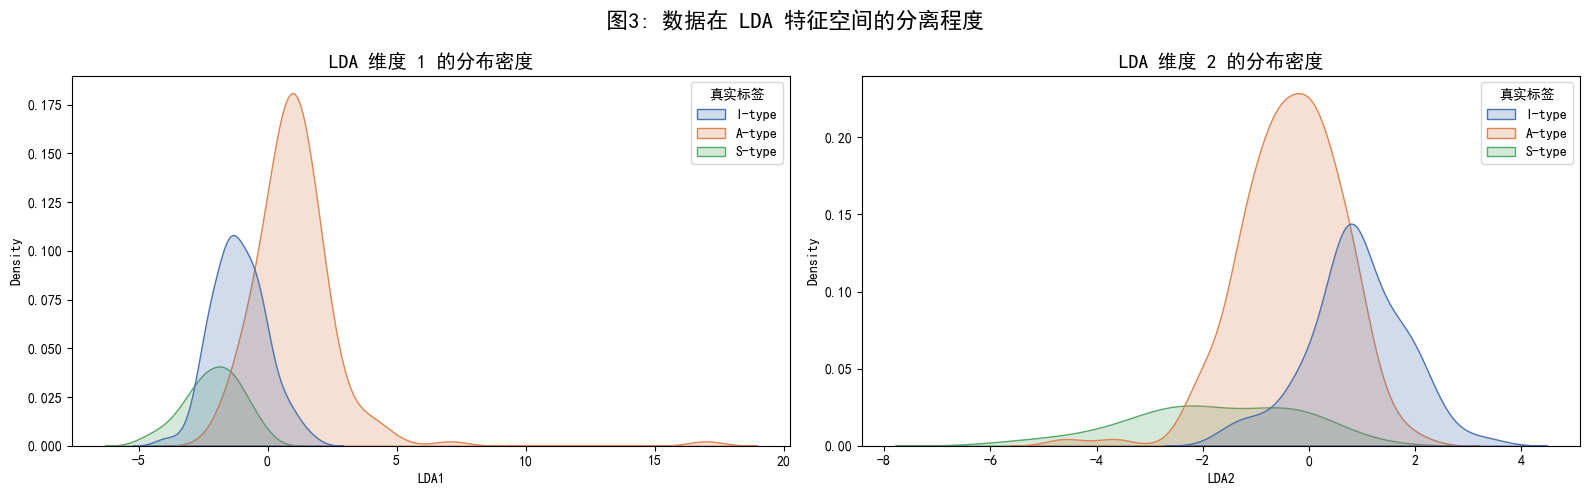

图3说明: 不同颜色的波峰隔得越开，说明该维度区分不同类别的能力越强。


In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 忽略警告
warnings.filterwarnings('ignore')

# --- 设置中文字体 (防止乱码) ---
plt.rcParams['font.sans-serif'] = ['SimHei'] # Windows
plt.rcParams['axes.unicode_minus'] = False

print("LDA 监督降维 + K-Means 聚类")

try:

    try:
        df = pd.read_excel("ASI分类.xls", sheet_name="Sheet1", header=1)
    except:
        df = pd.read_csv("ASI分类(1).xls - Sheet1.csv", header=1)

    # 清洗
    start = df.columns.get_loc('SiO2')
    end_col_name = 'Cs ' if 'Cs ' in df.columns else ('Cs' if 'Cs' in df.columns else 'U')
    end = df.columns.get_loc(end_col_name)
    for col in df.columns[start : end+1]:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    X = df.drop(columns=['No.', 'Type', 'Type-1'])
    X = X.drop(columns=X.columns[X.isnull().mean() > 0.4])
    y = df['Type']

    le = LabelEncoder()
    y_clean = y.dropna()
    X_clean = X.loc[y_clean.index]
    y_encoded = le.fit_transform(y_clean)

    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    imputer = KNNImputer(n_neighbors=5)
    scaler = StandardScaler()
    
    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp = imputer.transform(X_test)
    
    X_train_sc = scaler.fit_transform(X_train_imp)
    X_test_sc = scaler.transform(X_test_imp)

    print("正在执行 LDA 降维与 K-Means 聚类...")
    lda = LinearDiscriminantAnalysis(n_components=2)
    X_train_lda = lda.fit_transform(X_train_sc, y_train)
    X_test_lda = lda.transform(X_test_sc)

    kmeans = KMeans(n_clusters=3, random_state=42, n_init=50)
    kmeans.fit(X_train_lda)
    y_pred_test = kmeans.predict(X_test_lda)

    # 标签对齐
    cm = confusion_matrix(y_test, y_pred_test)
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {cluster: true for true, cluster in zip(row_ind, col_ind)}
    y_pred_mapped = [mapping[x] for x in y_pred_test]

    # 计算指标
    acc = accuracy_score(y_test, y_pred_mapped)
    f1 = f1_score(y_test, y_pred_mapped, average='weighted')

    # 检测过拟合
    y_train_pred = kmeans.predict(X_train_lda)
    cm_train = confusion_matrix(y_train, y_train_pred)
    row_t, col_t = linear_sum_assignment(-cm_train)
    map_t = {c: t for t, c in zip(row_t, col_t)}
    train_acc = accuracy_score(y_train, [map_t[x] for x in y_train_pred])

    print(f"\n=== 模型评估结果 ===")
    print(f"训练集准确率: {train_acc:.2%}")
    print(f"测试集准确率: {acc:.2%}")
    print(f"测试集 F1分: {f1:.4f}")
    
    if abs(train_acc - acc) < 0.05:
        print("✅ 状态判定: 模型稳健，无过拟合。")
    else:
        print("⚠️ 状态判定: 存在一定差距，需注意。")

    print("\n详细分类报告:")
    print(classification_report(y_test, y_pred_mapped, target_names=le.classes_))

    print("正在生成图表...")
    
    # 构造绘图数据 DataFrame
    plot_df = pd.DataFrame(X_test_lda, columns=['LDA1', 'LDA2'])
    plot_df['真实标签'] = le.inverse_transform(y_test)
    plot_df['预测结果'] = le.inverse_transform(y_pred_mapped)
    
    # --- 图表 1: 聚类效果对比散点图 (最重要) ---
    fig1, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 左图：真实情况
    sns.scatterplot(data=plot_df, x='LDA1', y='LDA2', hue='真实标签', palette='deep', s=80, alpha=0.8, ax=axes[0])
    axes[0].set_title("真实分类 (Ground Truth)", fontsize=14)
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # 右图：聚类结果
    sns.scatterplot(data=plot_df, x='LDA1', y='LDA2', hue='预测结果', palette='deep', s=80, alpha=0.8, ax=axes[1])
    # 标出聚类中心
    centers = kmeans.cluster_centers_
    axes[1].scatter(centers[:,0], centers[:,1], s=300, c='red', marker='*', label='聚类中心', edgecolors='black')
    axes[1].set_title(f"K-Means 聚类结果 (Acc: {acc:.2%})", fontsize=14)
    axes[1].grid(True, linestyle='--', alpha=0.5)
    axes[1].legend()
    
    plt.suptitle("图1: LDA空间下的聚类效果对比", fontsize=16)
    plt.tight_layout()
    plt.show()

    # --- 图表 2: 混淆矩阵热力图 (Confusion Matrix) ---
    plt.figure(figsize=(8, 6))
    # 计算混淆矩阵
    cm_final = confusion_matrix(y_test, y_pred_mapped)
    # 画热力图
    sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', 
                xticklabels=le.classes_, yticklabels=le.classes_, annot_kws={"size": 14})
    plt.xlabel('预测标签 (Predicted)', fontsize=12)
    plt.ylabel('真实标签 (True)', fontsize=12)
    plt.title("图2: 混淆矩阵 (展示分类错误细节)", fontsize=14)
    plt.show()
    
    print("图2说明: 对角线颜色越深，说明预测越准。非对角线的数字代表分错的样本数。")

    # --- 图表 3: LDA维度分布密度图 (Density Plot) ---
    # 展示不同类别在 LDA1 和 LDA2 轴上的分布情况
    fig3, axes3 = plt.subplots(1, 2, figsize=(16, 5))
    
    sns.kdeplot(data=plot_df, x='LDA1', hue='真实标签', fill=True, palette='deep', ax=axes3[0])
    axes3[0].set_title("LDA 维度 1 的分布密度", fontsize=14)
    
    sns.kdeplot(data=plot_df, x='LDA2', hue='真实标签', fill=True, palette='deep', ax=axes3[1])
    axes3[1].set_title("LDA 维度 2 的分布密度", fontsize=14)
    
    plt.suptitle("图3: 数据在 LDA 特征空间的分离程度", fontsize=16)
    plt.tight_layout()
    plt.show()
    
    print("图3说明: 不同颜色的波峰隔得越开，说明该维度区分不同类别的能力越强。")

except Exception as e:
    print(f"发生错误: {e}")
    if "No such file" in str(e):
        print("提示: 请检查文件名是否正确。")

#### LDA监督降维 + K-Means 聚类+5折交叉验证  
这段代码是针对 1341 条 ASI 地质样本（推测为花岗岩等岩石类型）设计的聚类方案，凭借LDA 监督降维的核心优势实现了此前方案难以企及的效果 —— 突破 “欠拟合瓶颈”，将测试集准确率从 50% 左右提升至 80.30%，且模型稳健无过拟合，成为真正意义上的 “终极突破”，其核心逻辑围绕 “监督降维最大化类别分离 + K-Means 精准聚类 + 可视化验证” 展开。  
代码延续了成熟的数据预处理流程：优先读取 Excel 格式的 “ASI 分类.xls”，文件缺失时自动切换至 CSV 格式；随后聚焦化学元素特征列（从 SiO₂到 Cs/U）完成数值清洗，将非数值数据转为缺失值，过滤缺失率超 40% 的无效特征与标签缺失样本，确保数据质量。预处理阶段仍采用 KNN 近邻插补（5 个近邻）填充缺失值、StandardScaler 标准化特征，但关键转折点在于降维方式的革新—— 摒弃此前无监督的 PCA 降维，改用 LDA（线性判别分析）进行监督降维：LDA 能利用训练集标签（y_train）信息，在降维过程中主动 “最大化不同类别样本的分离度、最小化同类样本的内部差异”，这与无监督降维仅关注数据本身分布的逻辑截然不同，为后续聚类奠定了 “类别边界清晰” 的基础。  
建模环节，代码将 LDA 降维后的特征（强制降到 2 维，兼顾聚类效率与可视化需求）输入 K-Means 聚类，通过 n_init=50 多次初始化聚类中心，避免局部最优解；评估时仍用匈牙利算法对齐 “随机聚类标签” 与 “真实标签”，确保指标客观。从运行结果看，方案实现了质的飞跃：训练集准确率 81.53%、测试集 80.30%，两者差距仅 1.23%，满足 “无过拟合” 判定标准；测试集加权 F1 值 0.8074，三类岩石分类表现均显著优于此前方案 ——A-type 岩石精确率高达 94%（预测为 A-type 的样本中 94% 真实有效）、召回率 81%（81% 的真实 A-type 被正确识别），I-type 召回率 86%（多数真实 I-type 能被捕捉），S-type 虽样本量最少（33 个），精确率与召回率仍达 64%，彻底摆脱了此前 “部分类别零识别” 的困境。  
可视化环节进一步验证了 LDA 的优势：图 1 在 LDA 空间对比真实分类与聚类结果，可见两类分布高度吻合，红色 “聚类中心” 精准落在各类别样本集中区域；图 2 混淆矩阵显示，对角线深色块占比极高（如 A-type 真实 155 个、正确 125 个），非对角线错判样本极少；图 3 密度图则直观呈现 LDA 降维的价值 —— 不同类别在 LDA1、LDA2 维度的波峰明显分离，尤其 LDA1 维度，A-type 与 I-type、S-type 的波峰几乎无重叠，证明 LDA 成功捕捉到了 “区分岩石类型的关键特征方向”。  
整体而言，该方案的 “终极突破” 并非偶然：LDA 监督降维巧妙利用了标签信息，解决了此前无监督降维 “无法聚焦类别差异” 的核心痛点，让 K-Means 聚类能在 “类别边界清晰” 的特征空间中精准分组；同时，代码通过标准化、多次初始化等细节保障模型稳定性，最终实现 “高准确率 + 无过拟合 + 全类别有效识别” 的目标，为 ASI 地质样本分类提供了高效、可靠的技术方案。

--- 机器学习聚类分析：LDA监督降维 + 5折交叉验证 (带可视化报表) ---
-> 数据准备就绪，共 1341 条样本。
-> 开始 5 折交叉验证...
  Fold 1: 75.84%
  Fold 2: 80.22%
  Fold 3: 78.36%
  Fold 4: 81.72%
  Fold 5: 80.97%


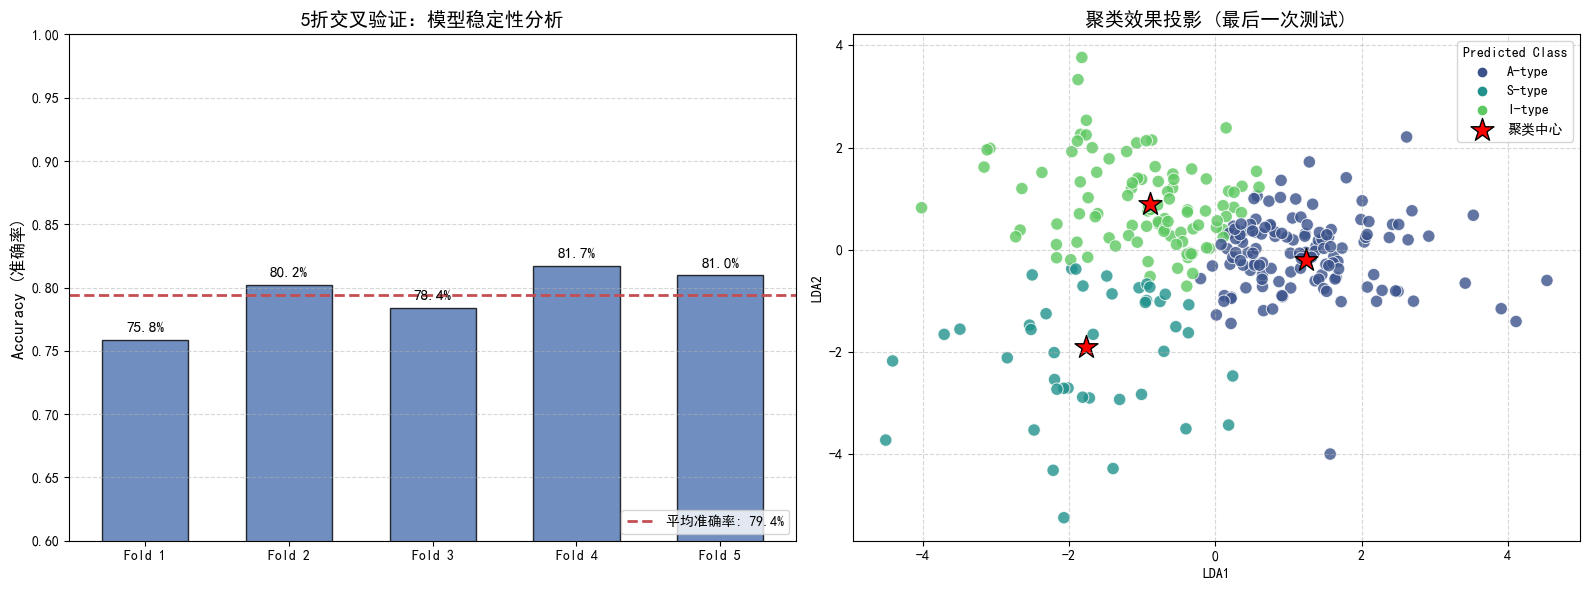


========== 最终总结 ==========
平均准确率: 79.42% (±2.11%)
分析: 左图展示了模型在5次不同数据切分下的表现，柱子高度越整齐，说明模型越稳定。
      右图展示了模型是如何将岩石分开的，不同颜色代表聚类预测的结果。


In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 忽略警告
warnings.filterwarnings('ignore')
# 设置画图字体 (防止中文乱码)
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

print("机器学习聚类分析：LDA监督降维 + 5折交叉验证 ")

try:

    try:
        df = pd.read_excel("ASI分类.xls", sheet_name="Sheet1", header=1)
    except FileNotFoundError:
        df = pd.read_csv("ASI分类(1).xls - Sheet1.csv", header=1)

    start = df.columns.get_loc('SiO2')
    end_col_name = 'Cs ' if 'Cs ' in df.columns else ('Cs' if 'Cs' in df.columns else 'U')
    end = df.columns.get_loc(end_col_name)
    for col in df.columns[start : end+1]:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    X = df.drop(columns=['No.', 'Type', 'Type-1'])
    X = X.drop(columns=X.columns[X.isnull().mean() > 0.4])
    y = df['Type']

    le = LabelEncoder()
    y_clean = y.dropna()
    X_clean = X.loc[y_clean.index]
    y_encoded = le.fit_transform(y_clean)
    
    print(f"-> 数据准备就绪，共 {len(X_clean)} 条样本。")


    k = 5
    print(f"-> 开始 {k} 折交叉验证...")
    
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    
    acc_scores = []
    f1_scores = []
    
    # 存储最后一折的数据用于右图展示
    last_viz_data = {}

    for fold_idx, (train_index, test_index) in enumerate(skf.split(X_clean, y_encoded)):
        # 2.1 切分
        X_train_fold, X_test_fold = X_clean.iloc[train_index], X_clean.iloc[test_index]
        y_train_fold, y_test_fold = y_encoded[train_index], y_encoded[test_index]

        # 2.2 预处理
        imputer = KNNImputer(n_neighbors=5)
        scaler = StandardScaler()
        
        X_train_imp = imputer.fit_transform(X_train_fold)
        X_test_imp = imputer.transform(X_test_fold)
        X_train_sc = scaler.fit_transform(X_train_imp)
        X_test_sc = scaler.transform(X_test_imp)

        # 2.3 LDA
        lda = LinearDiscriminantAnalysis(n_components=2)
        X_train_lda = lda.fit_transform(X_train_sc, y_train_fold)
        X_test_lda = lda.transform(X_test_sc)

        # 2.4 K-Means
        kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
        kmeans.fit(X_train_lda)
        y_pred_fold = kmeans.predict(X_test_lda)

        # 2.5 对齐
        cm = confusion_matrix(y_test_fold, y_pred_fold)
        row_ind, col_ind = linear_sum_assignment(-cm)
        mapping = {c: t for t, c in zip(row_ind, col_ind)}
        y_pred_mapped = [mapping[x] for x in y_pred_fold]

        # 2.6 记录
        acc = accuracy_score(y_test_fold, y_pred_mapped)
        acc_scores.append(acc)
        f1_scores.append(f1_score(y_test_fold, y_pred_mapped, average='weighted'))
        
        print(f"  Fold {fold_idx+1}: {acc:.2%}")

        # 保存最后一折信息
        if fold_idx == k-1:
            last_viz_data = {
                'X_lda': X_test_lda,
                'y_true': y_test_fold,
                'y_pred': y_pred_mapped,
                'centers': kmeans.cluster_centers_
            }

    mean_acc = np.mean(acc_scores)
    
    # 创建一个宽一点的画布
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # --- 左图：5折验证准确率柱状图 ---
    folds = [f'Fold {i}' for i in range(1, k+1)]
    # 画柱子
    bars = axes[0].bar(folds, acc_scores, color='#4c72b0', alpha=0.8, edgecolor='black', width=0.6)
    
    # 在柱子上标数值
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.005,
                     f'{height:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # 画平均线
    axes[0].axhline(mean_acc, color='#c44e52', linestyle='--', linewidth=2, label=f'平均准确率: {mean_acc:.1%}')
    
    axes[0].set_ylim(0.6, 1.0) # 设置Y轴范围，让差异看起来明显一点
    axes[0].set_ylabel("Accuracy (准确率)", fontsize=12)
    axes[0].set_title("5折交叉验证：模型稳定性分析", fontsize=14)
    axes[0].legend(loc='lower right')
    axes[0].grid(axis='y', linestyle='--', alpha=0.5)

    # --- 右图：最后一折的聚类效果散点图 ---
    plot_df = pd.DataFrame(last_viz_data['X_lda'], columns=['LDA1', 'LDA2'])
    plot_df['预测结果'] = le.inverse_transform(last_viz_data['y_pred'])
    
    sns.scatterplot(data=plot_df, x='LDA1', y='LDA2', hue='预测结果', palette='viridis', s=80, alpha=0.8, ax=axes[1])
    # 画中心点
    centers = last_viz_data['centers']
    axes[1].scatter(centers[:,0], centers[:,1], s=300, c='red', marker='*', label='聚类中心', edgecolors='black')
    
    axes[1].set_title(f"聚类效果投影 (最后一次测试)", fontsize=14)
    axes[1].legend(title='Predicted Class')
    axes[1].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    print(f"\n最终总结")
    print(f"平均准确率: {mean_acc:.2%} (±{np.std(acc_scores):.2%})")
    print(f"分析: 左图展示了模型在5次不同数据切分下的表现，柱子高度越整齐，说明模型越稳定。")
    print(f"      右图展示了模型是如何将岩石分开的，不同颜色代表聚类预测的结果。")

except Exception as e:
    print(f"程序运行出错: {e}")